In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
from scipy.signal import savgol_filter

# set simulation parameters
temp = 900.0
tau0 = 150.0
lgb = 0.1
delta = 0.004
ngbn = int(lgb/delta)
if ngbn % 2 == 0: ngbn += 1
dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
#grain_size = 1.0
maxout = 1000
tfin = 1.5e9
niter = 500_000_000

# define grain sizes or files
flist = ["pu1_tau150_T500_D3_L1", "pu1_tau150_T500_D10_L1",
         "pu1_tau150_T500_D30_L1", "pu1_tau150_T500_D100_L1",
         "pu1_tau150_T500_D300_L1", #"pu1_tau150_T900_D1000_L1",
        ]
path = "../examples/Res-PU1-v2_2_2-Z2/"
#path = "./PU1_conv_nbgn/"
Np = len(flist)
#D2_list = [1]
#Np = len(D2_list)

# initialize arrays to store results
psr_av = np.zeros((Np, maxout))
gplast = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
gs_list = np.zeros(Np)

In [2]:
def plot_stress_bfield(npt = 300, file=None, cutoff=100.):
    xpts = np.linspace(0.0, dsl.lx, npt)
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i], YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i])
    extent = (0.0, dsl.lx, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu], dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.08)
    #cbar.set_label(r"$\sigma_{12}$ (MPa)")
    cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:], dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(0., dsl.by[npu:].max())
    ax2.invert_yaxis()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    ax2.set_position([
        pos1.x0,
        pos2.y0,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b_y \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()

In [ ]:
# run simulations
for i, gs in enumerate(D2_list):
    print(f"Simulation with N_gbn={ngbn}, grain_size={gs}, dtmax={dtmax}")
    gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                       Ngbn=ngbn, len_gb_seg=lgb, grain_size=gs,
                       tfin=tfin, niter=niter, maxout=maxout,
                       dtmax=dtmax,
                       screenout=True)
    gbdd.run_sim()
    gbdd.save_hdf5(f"pu1_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.h5")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    #gbdd.plot_time_series('plastic_slip', fs=26, lw=3)
    gbdd.plot_time_series('psr_av', fs=26, lw=4,
                          file=f"pu1_gd_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('displacement', fs=26, lw=4, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('bfield', fs=26, lw=3, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    nit[i] = gbdd.nout
    gs_list[i] = gs
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']


Data file with D=0.3, delta=0.1, dtmax=2441.4062499999995


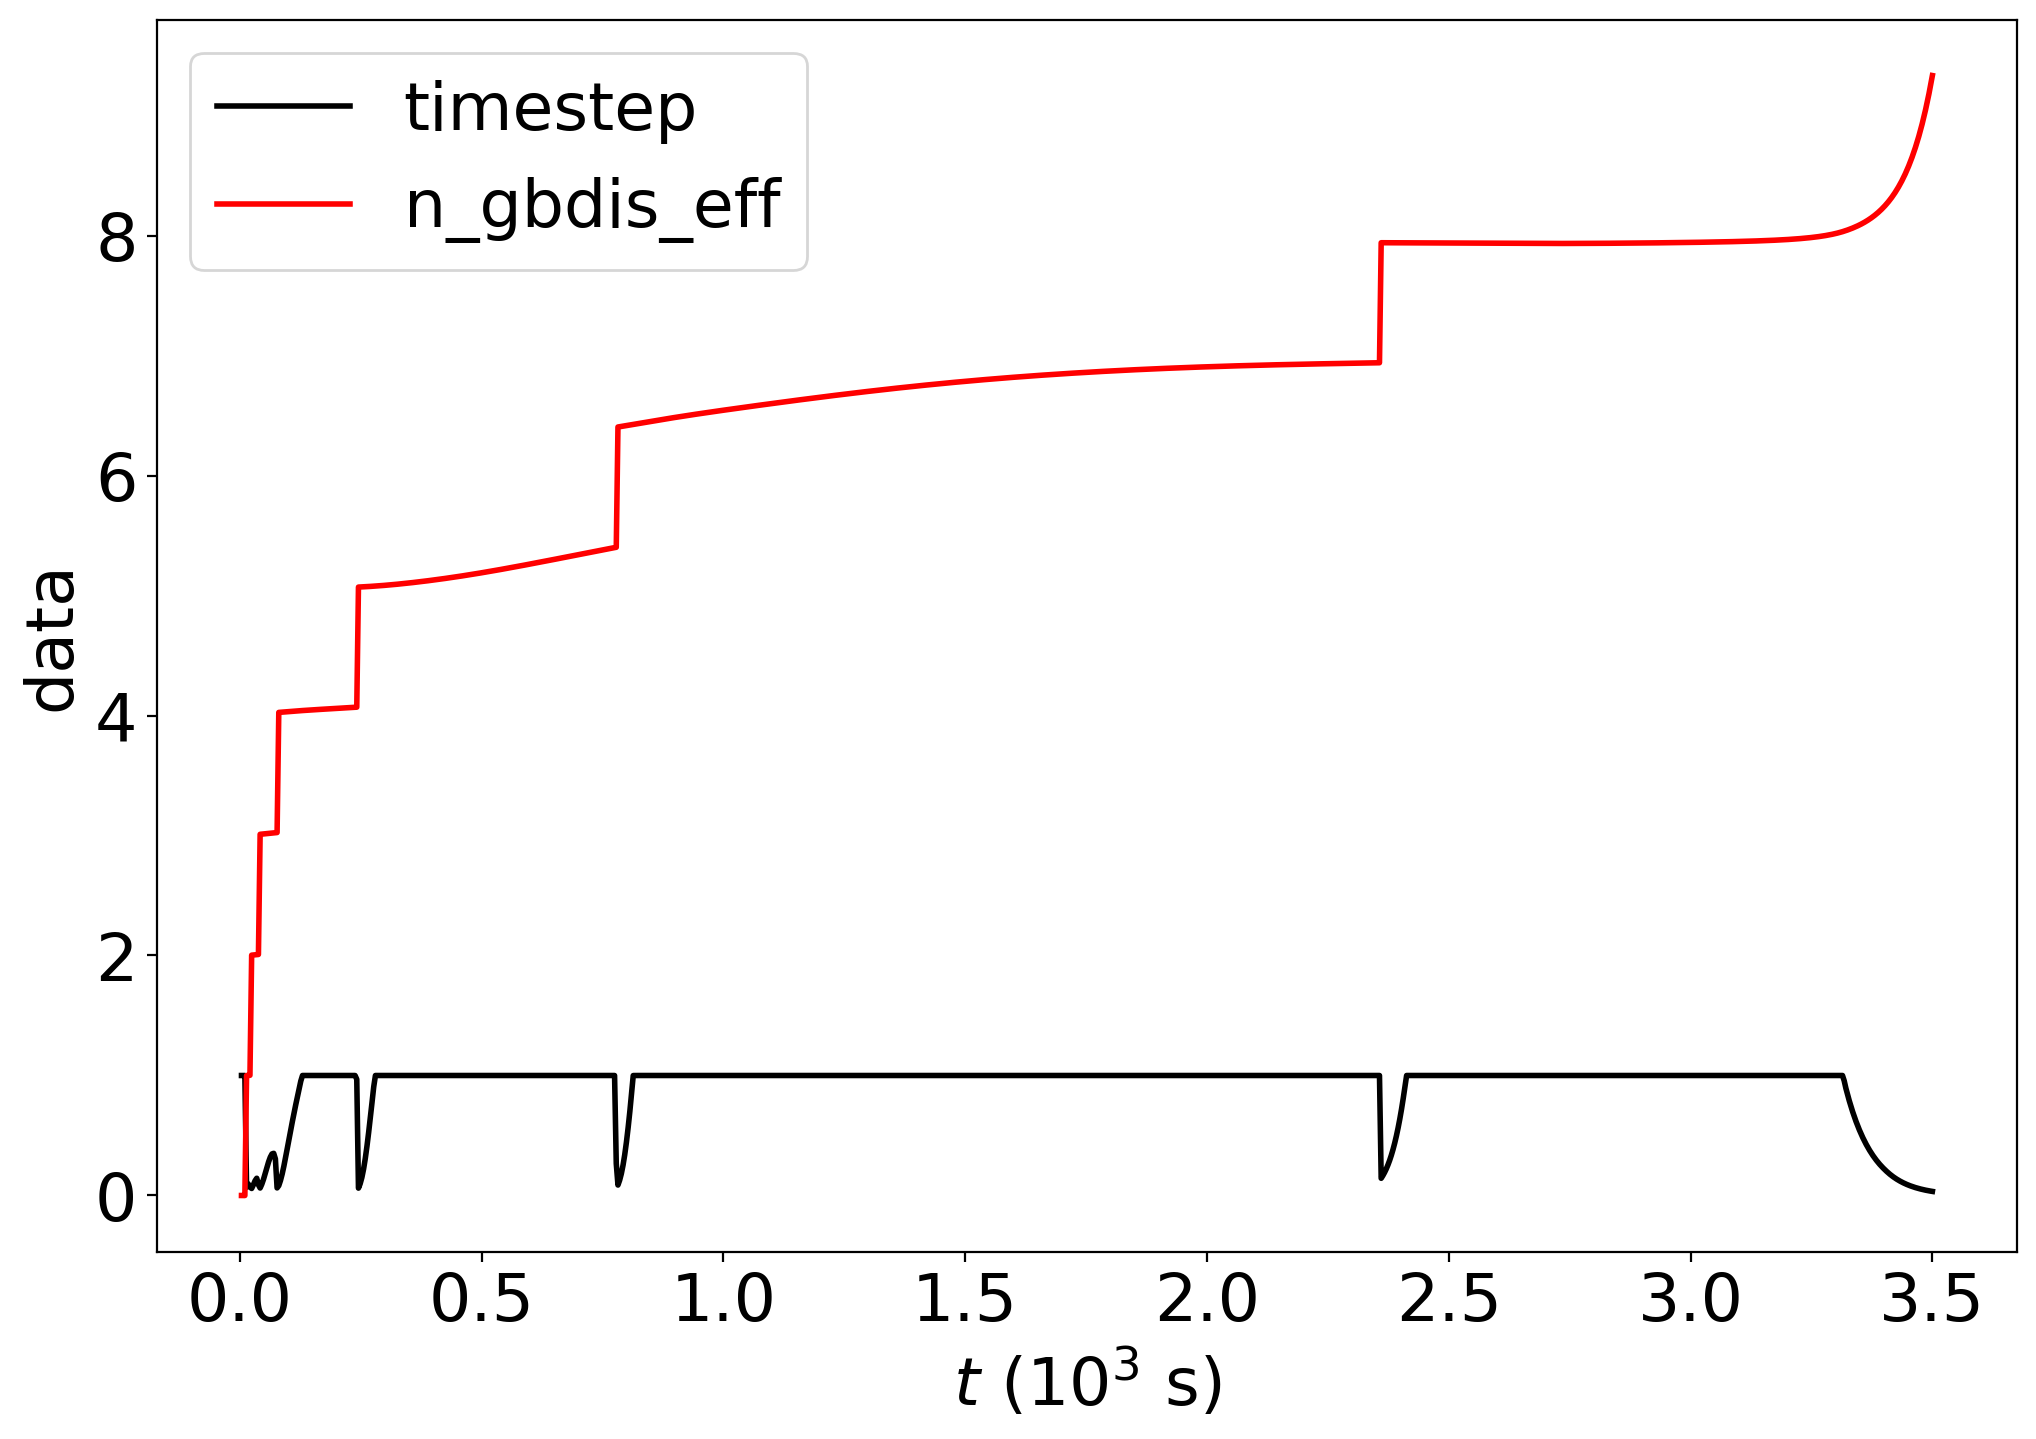

** Max. time step = 2441.406249999999, Median: 2441.406249999999


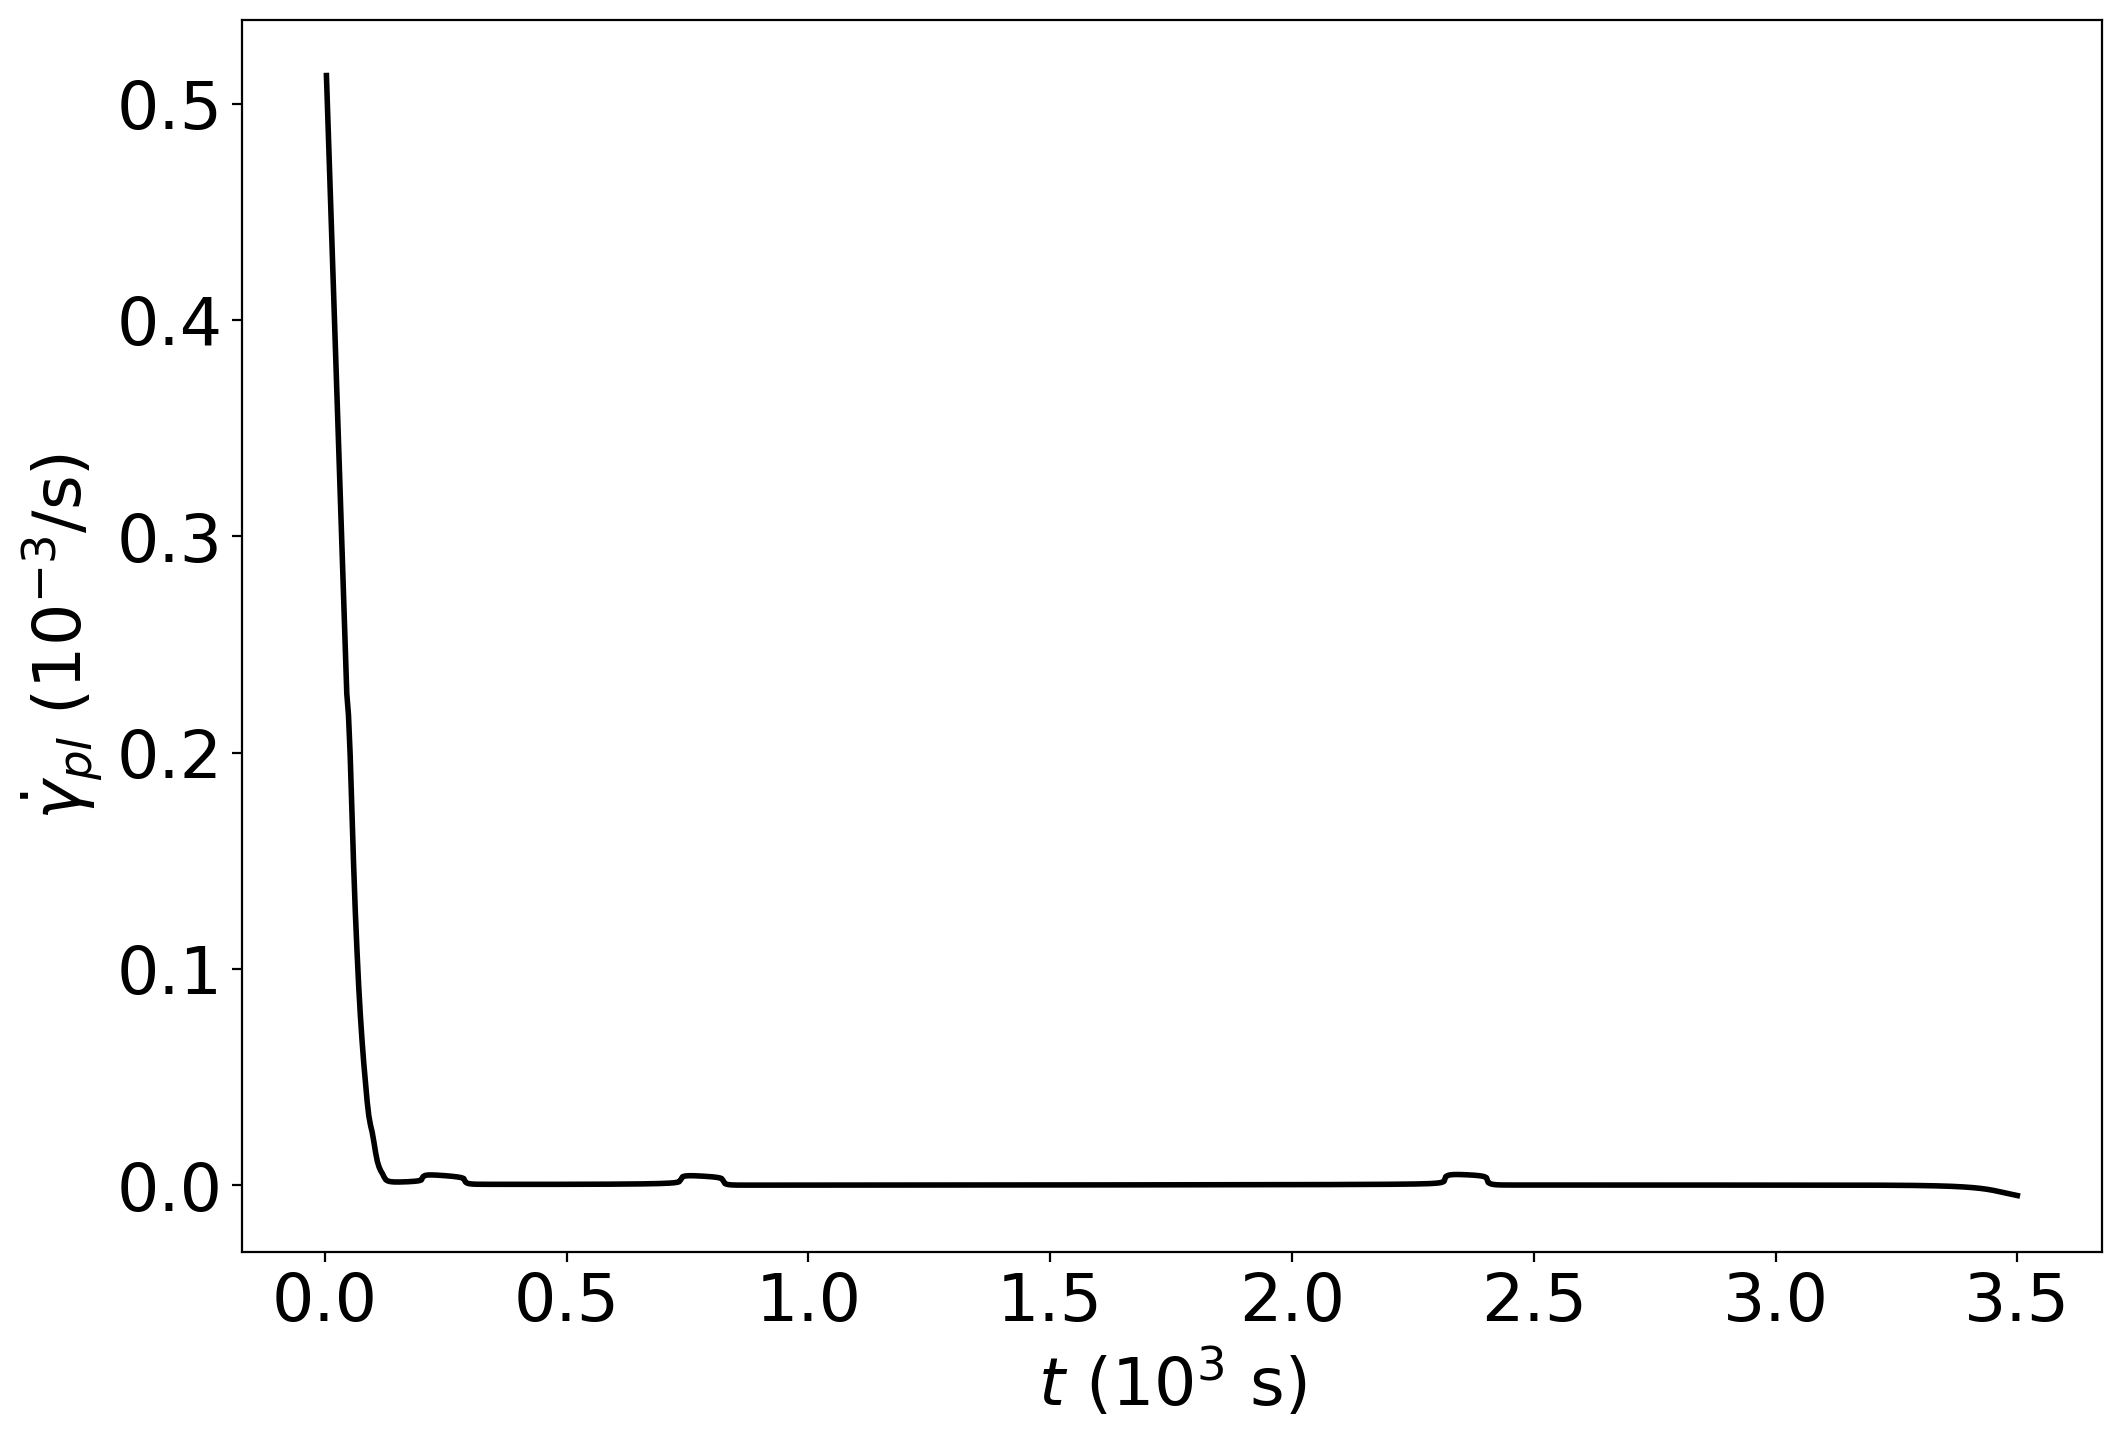

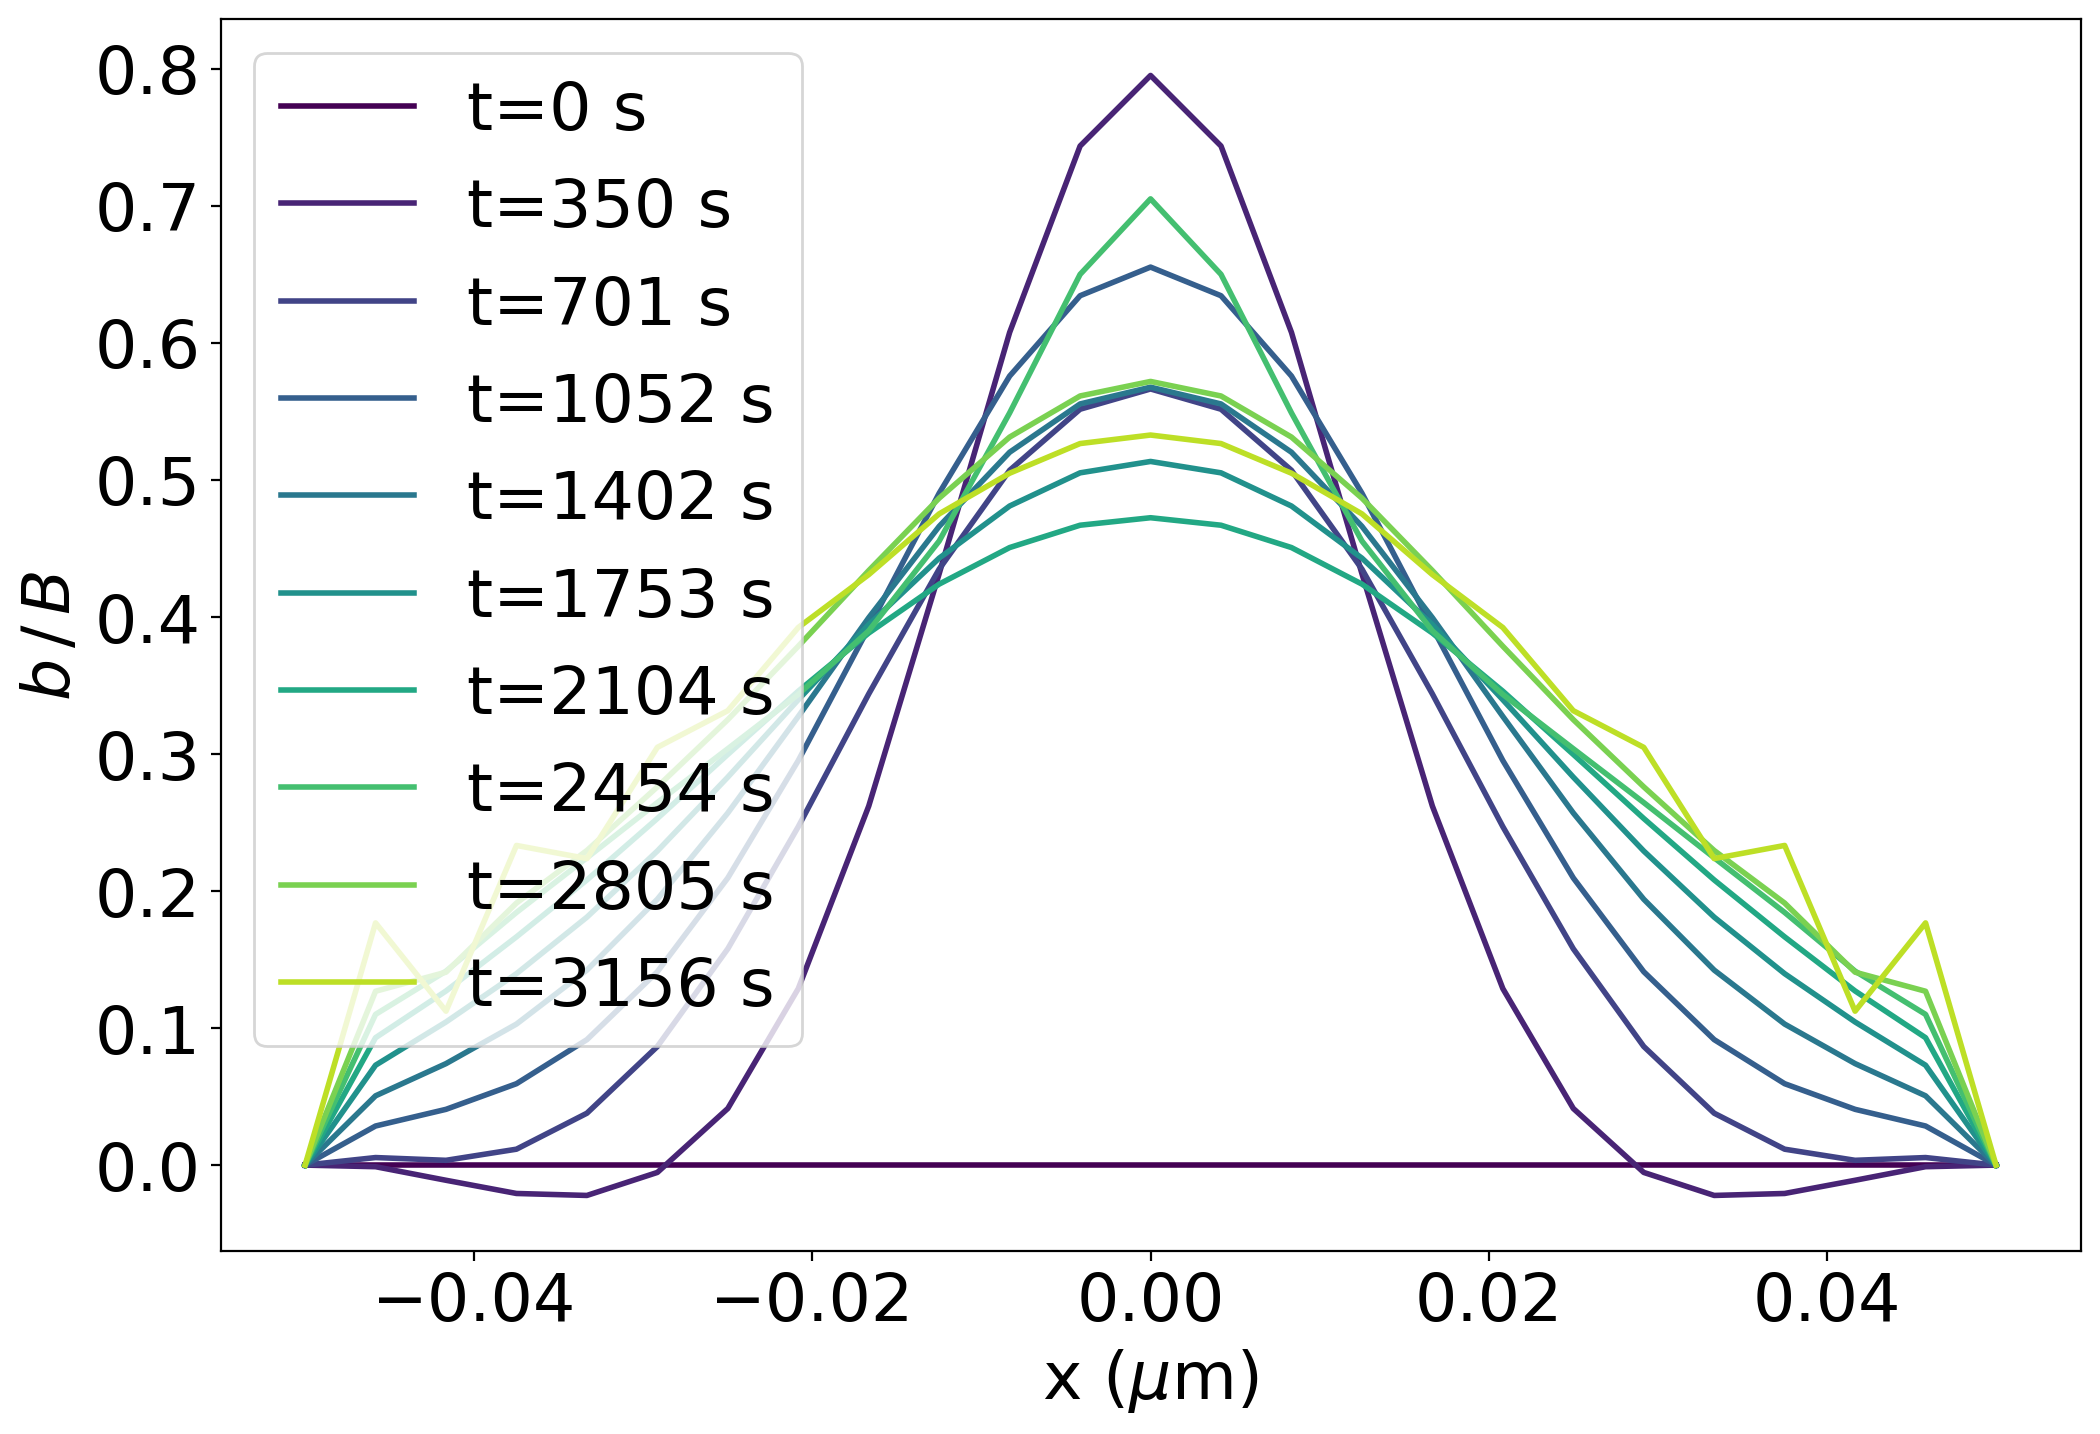

Data file with D=1.0, delta=0.1, dtmax=2441.4062499999995


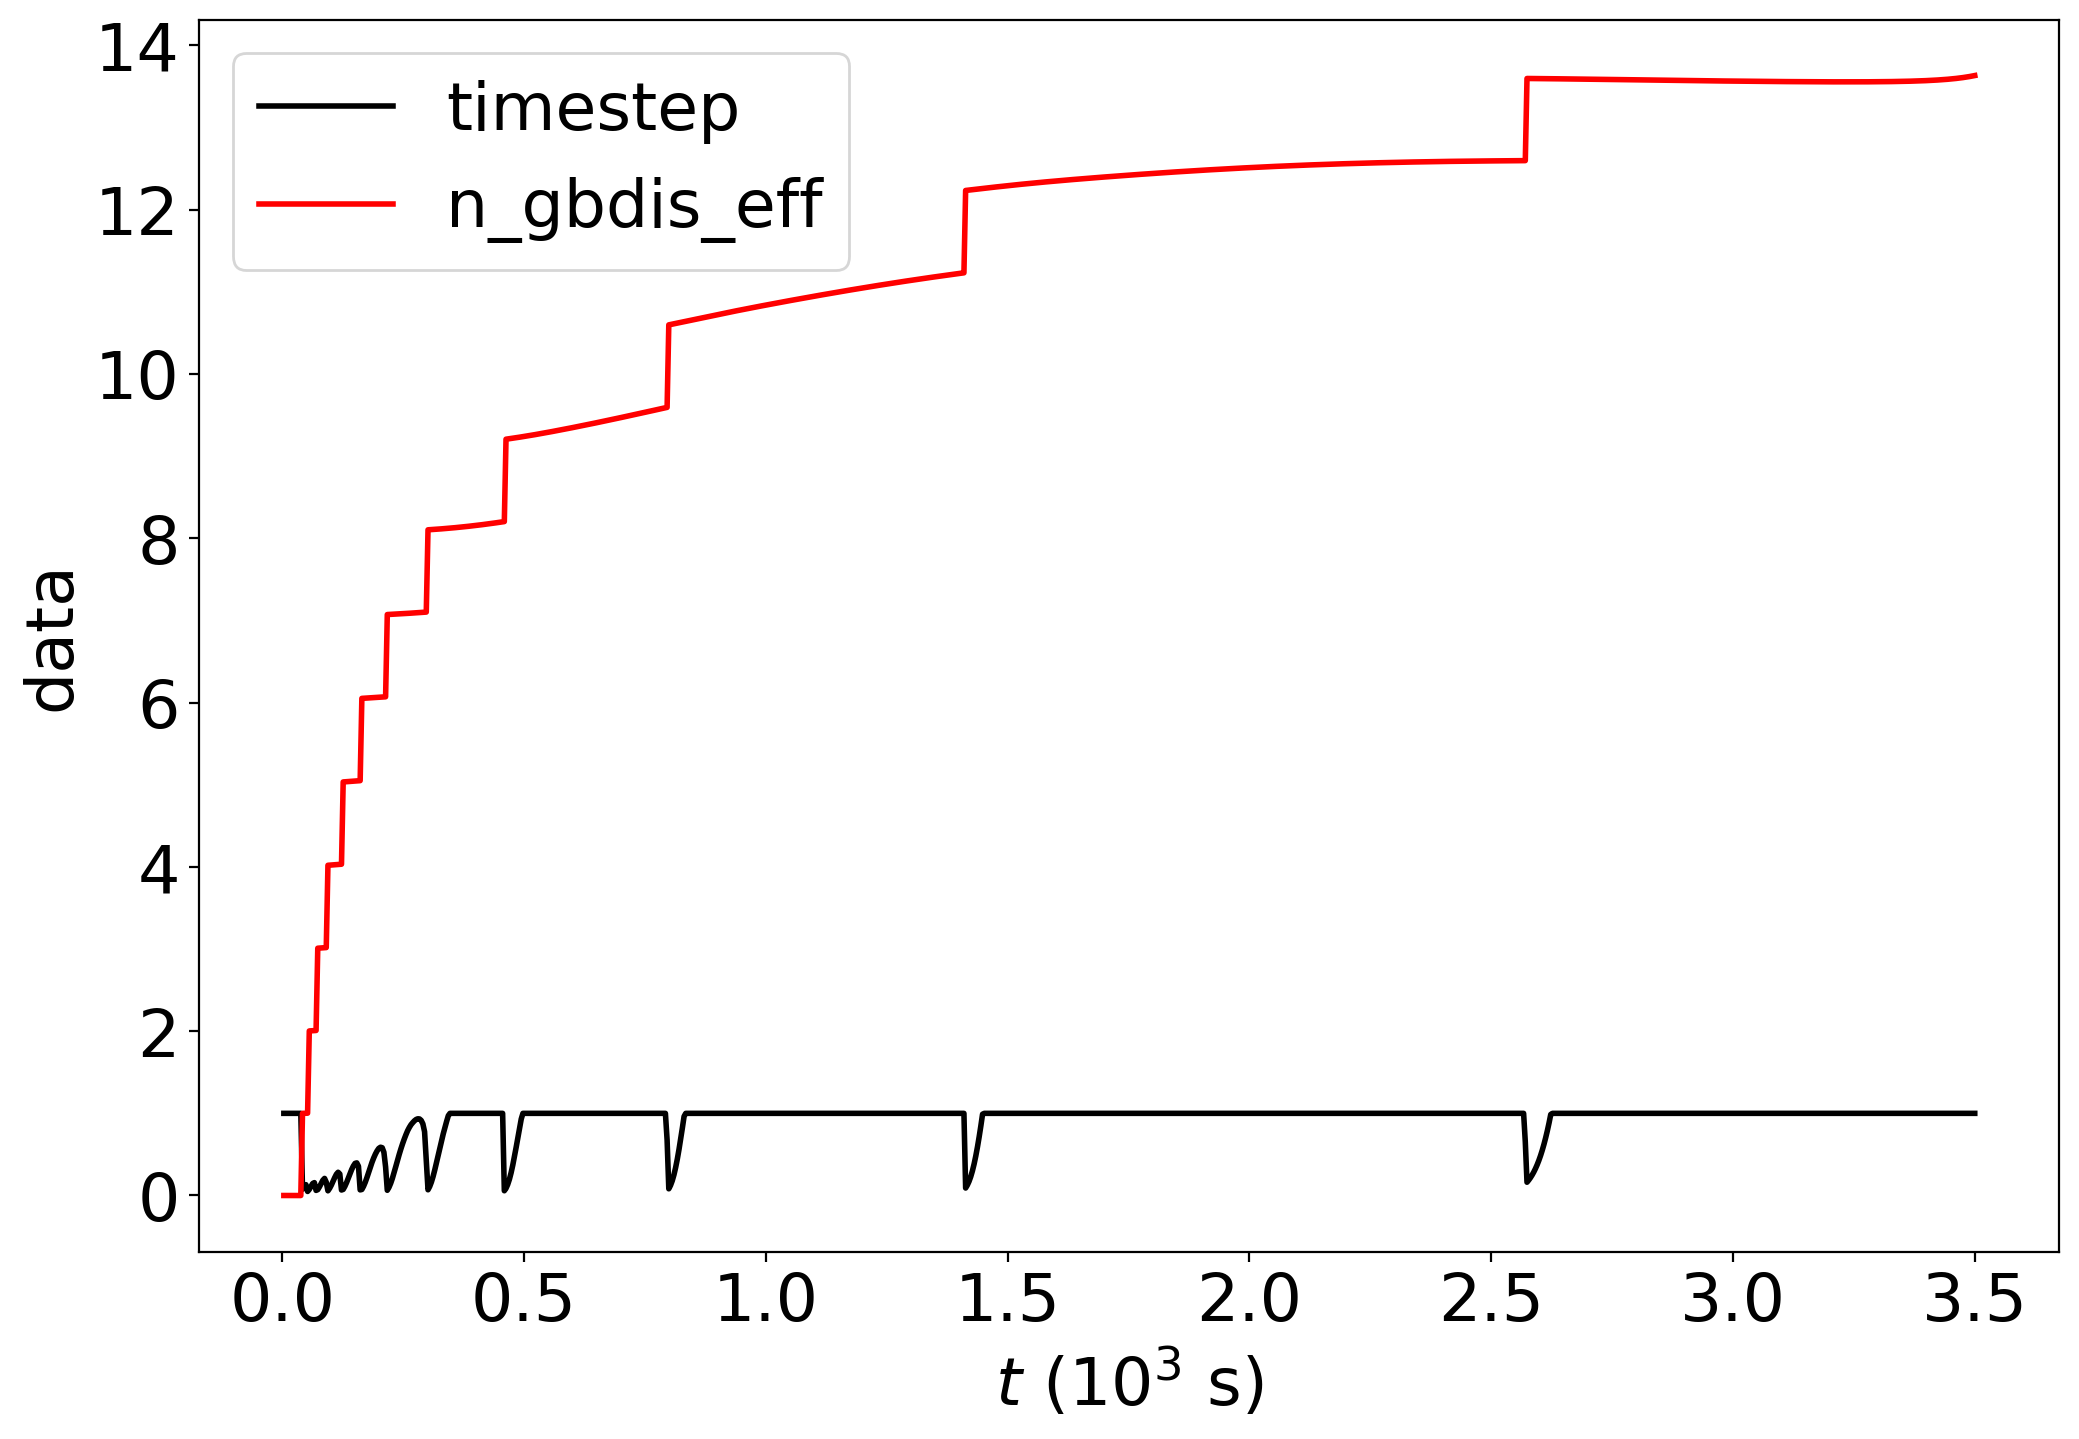

** Max. time step = 2441.406249999999, Median: 2441.406249999999


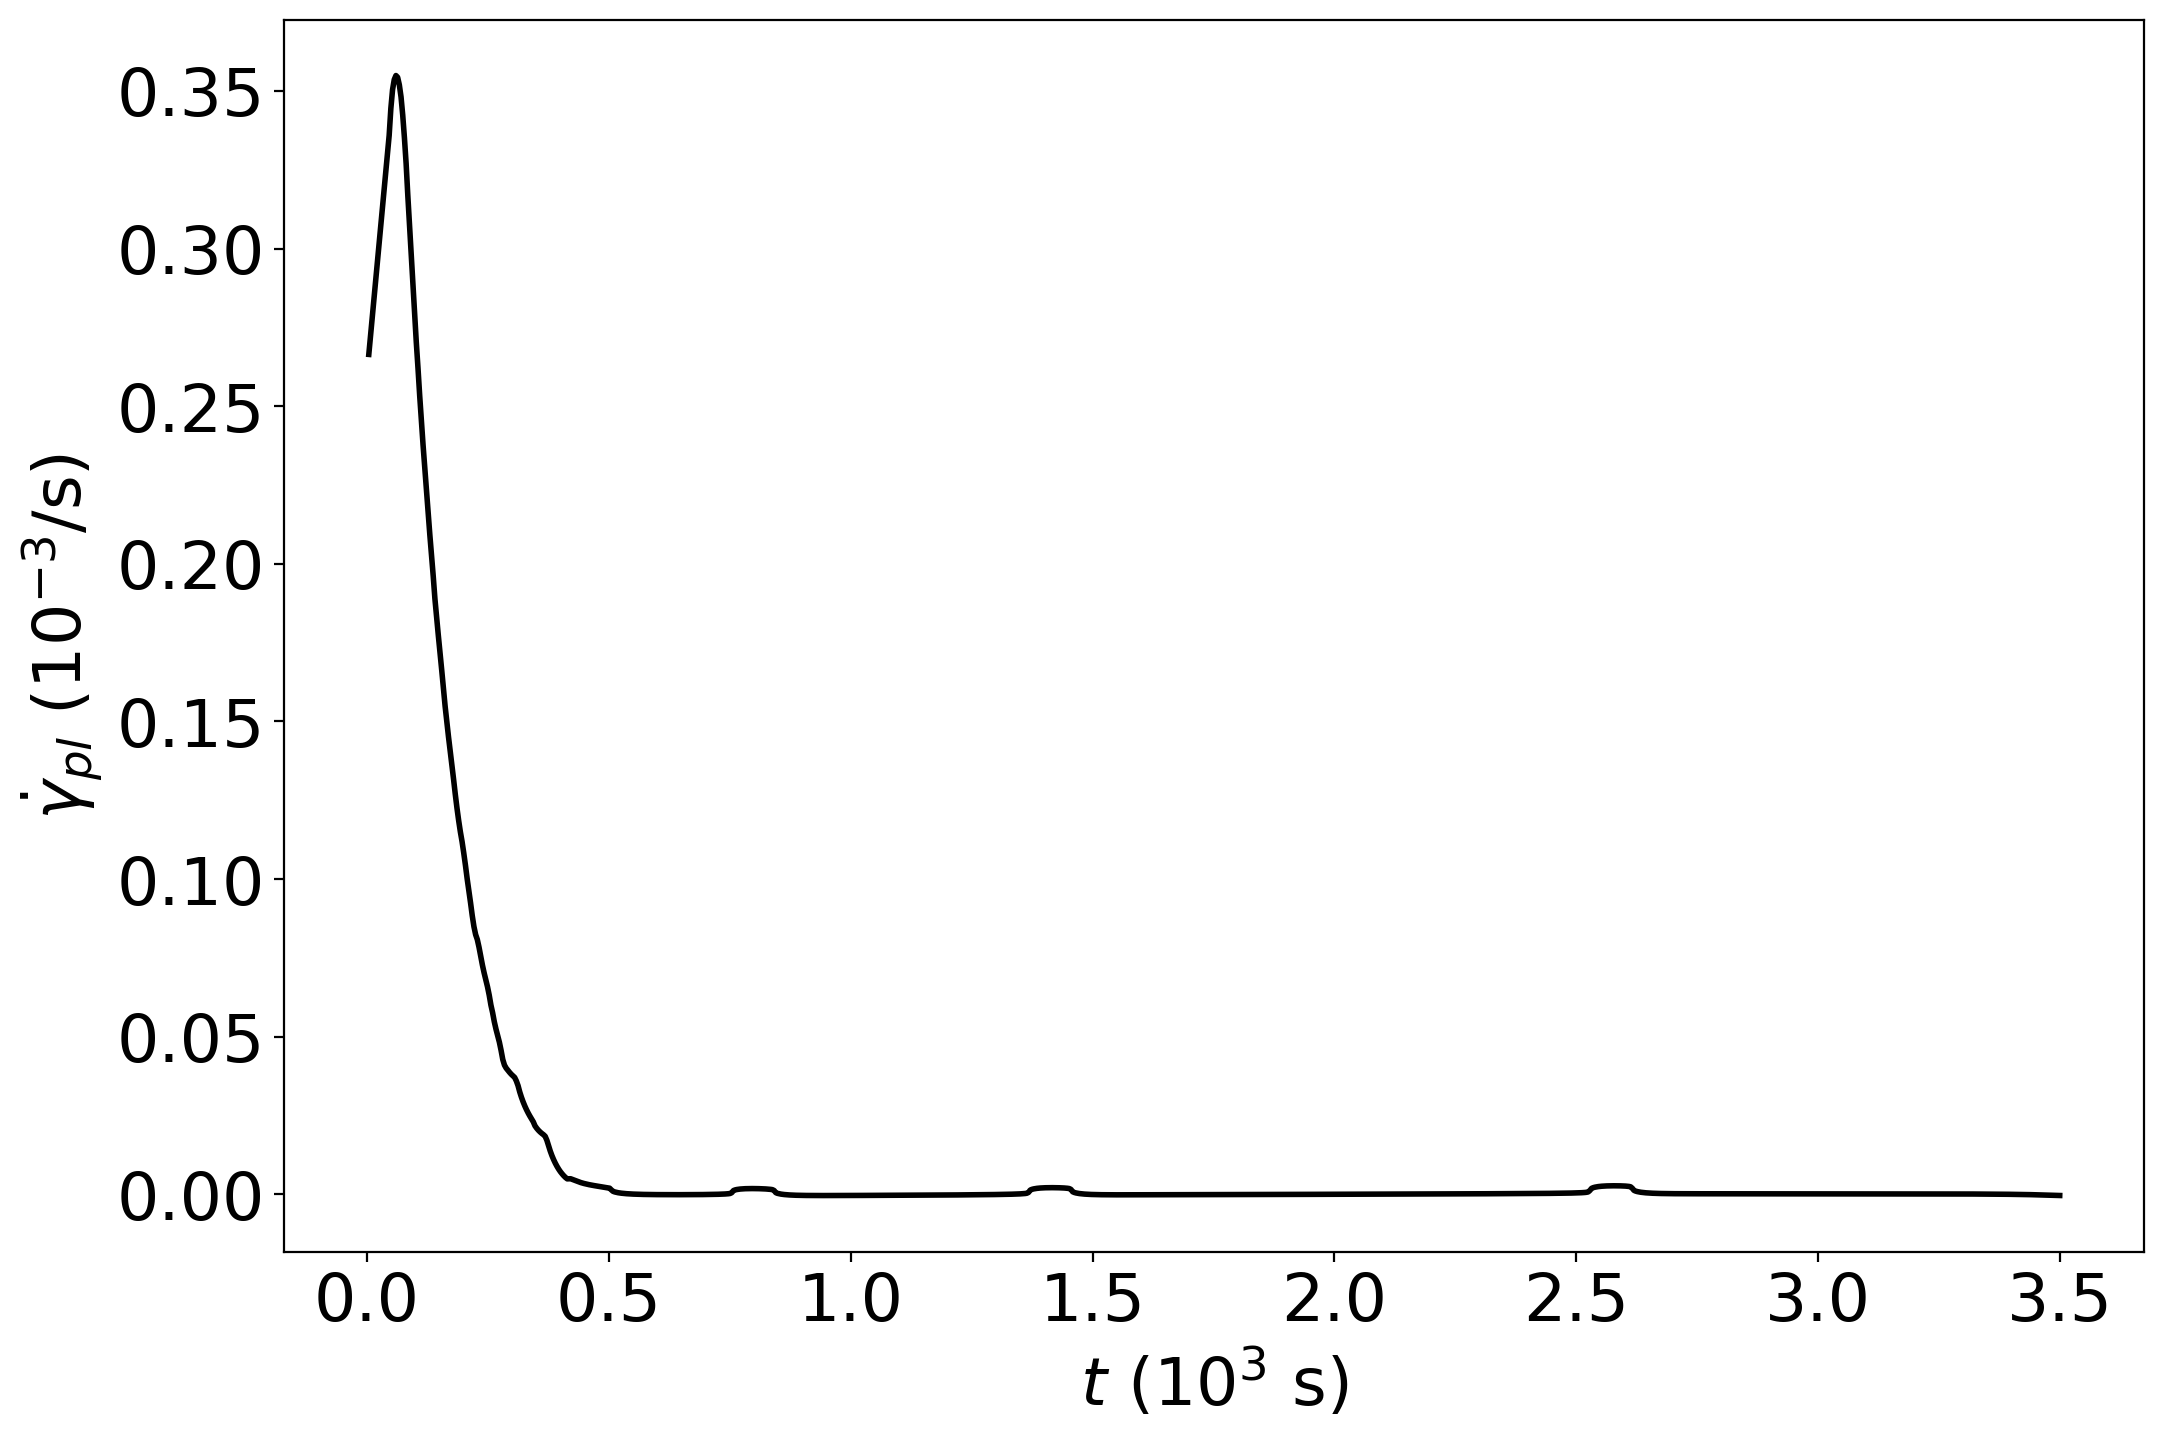

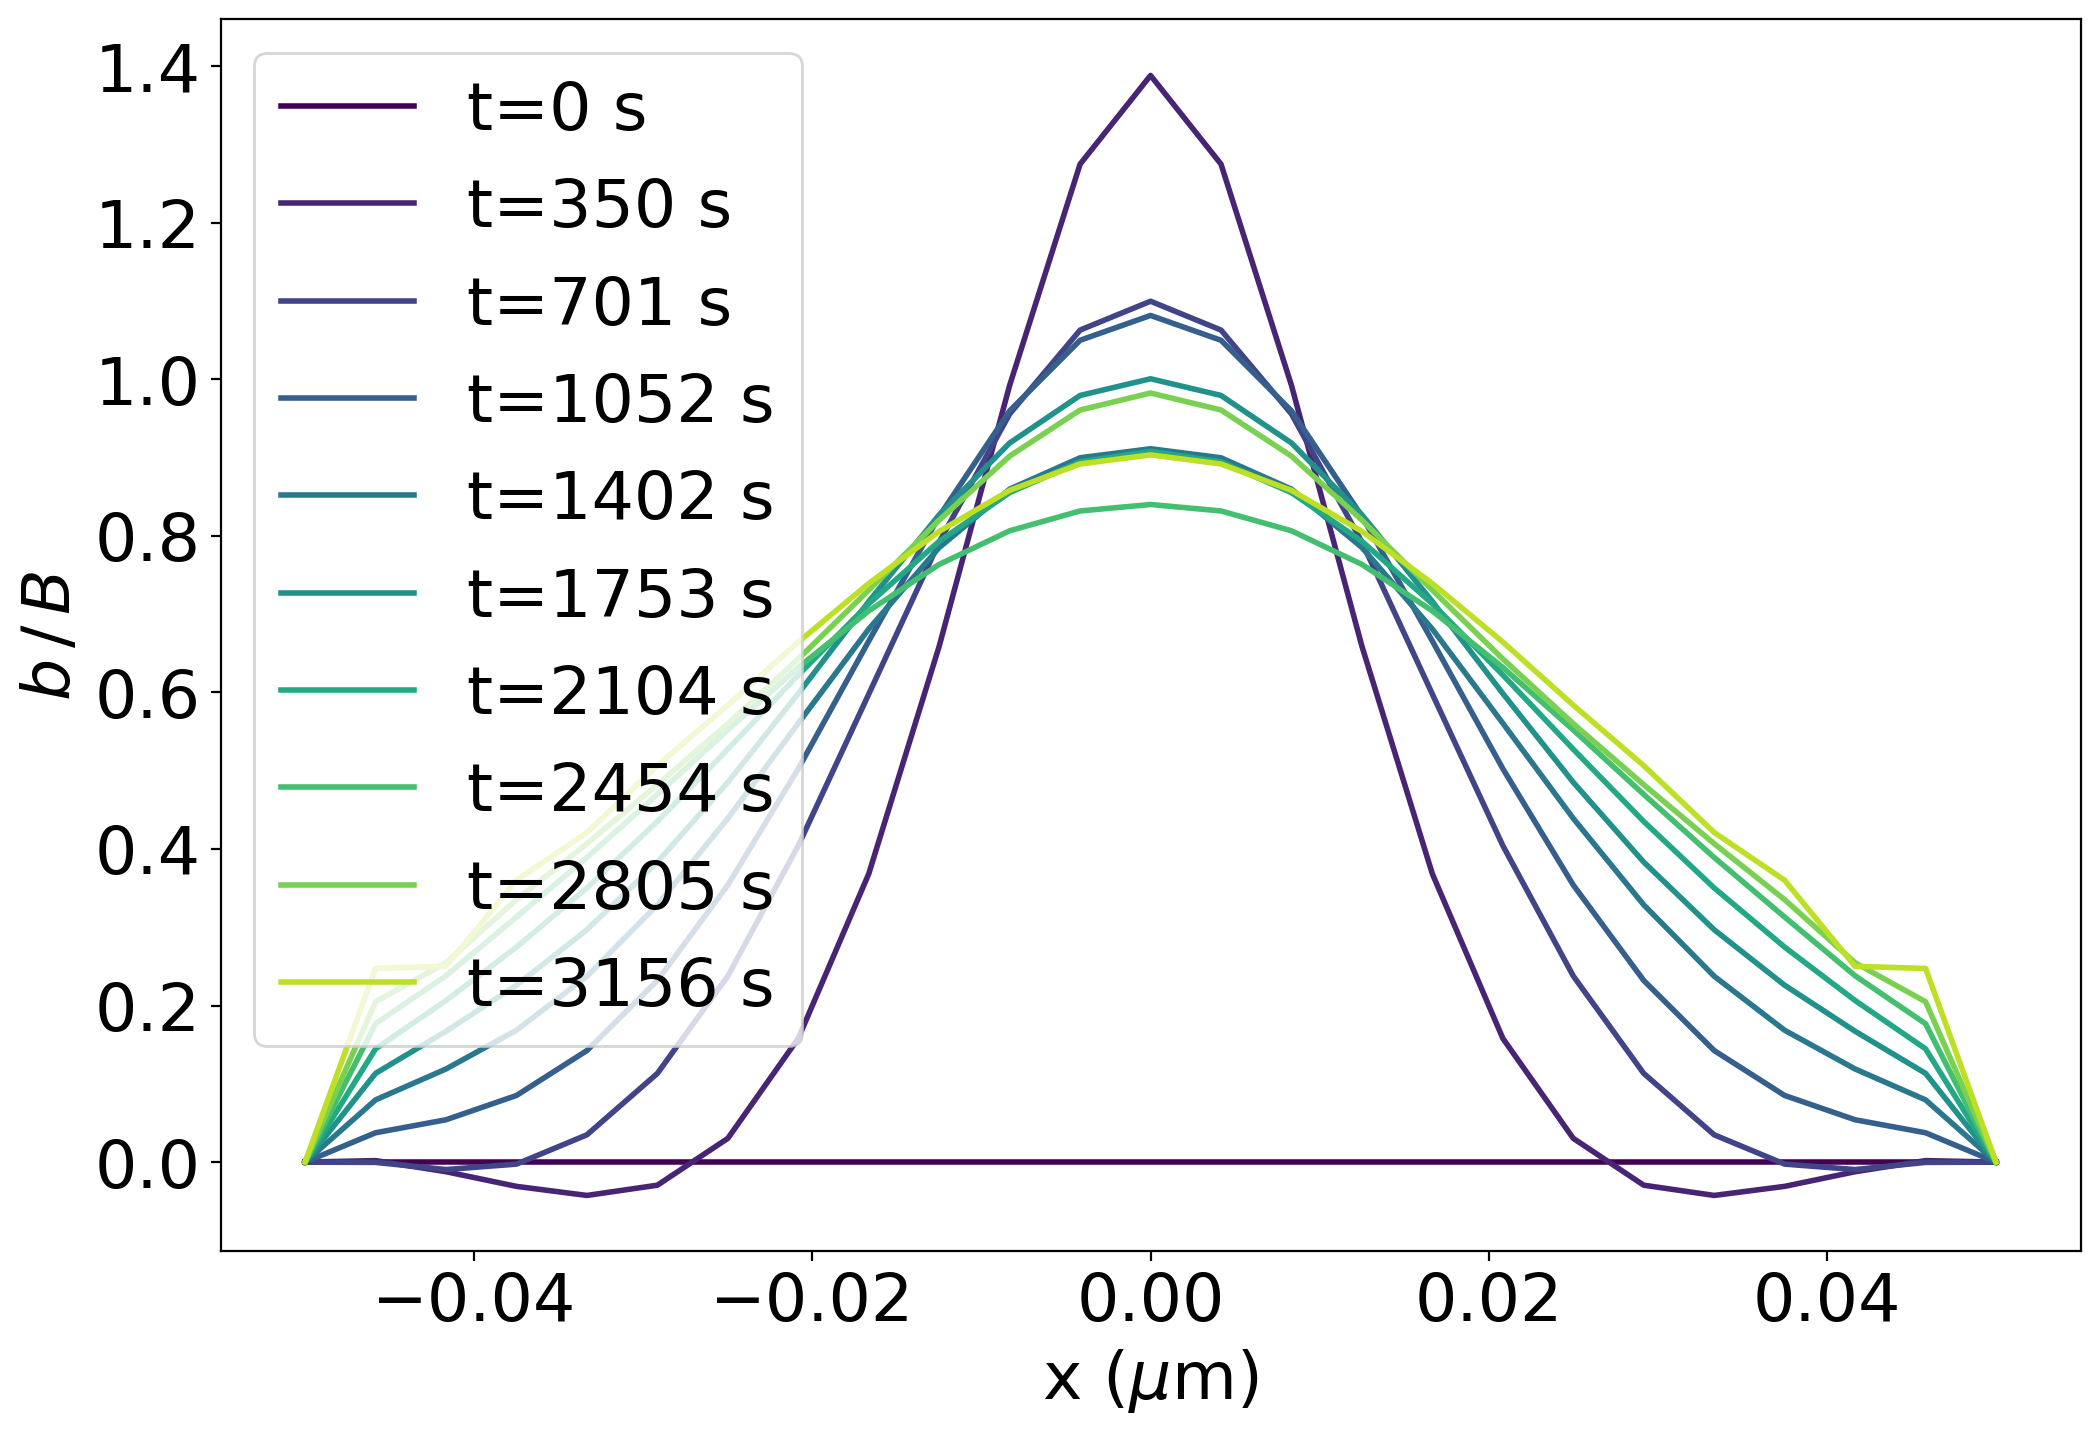

Data file with D=3.0, delta=0.1, dtmax=2441.4062499999995


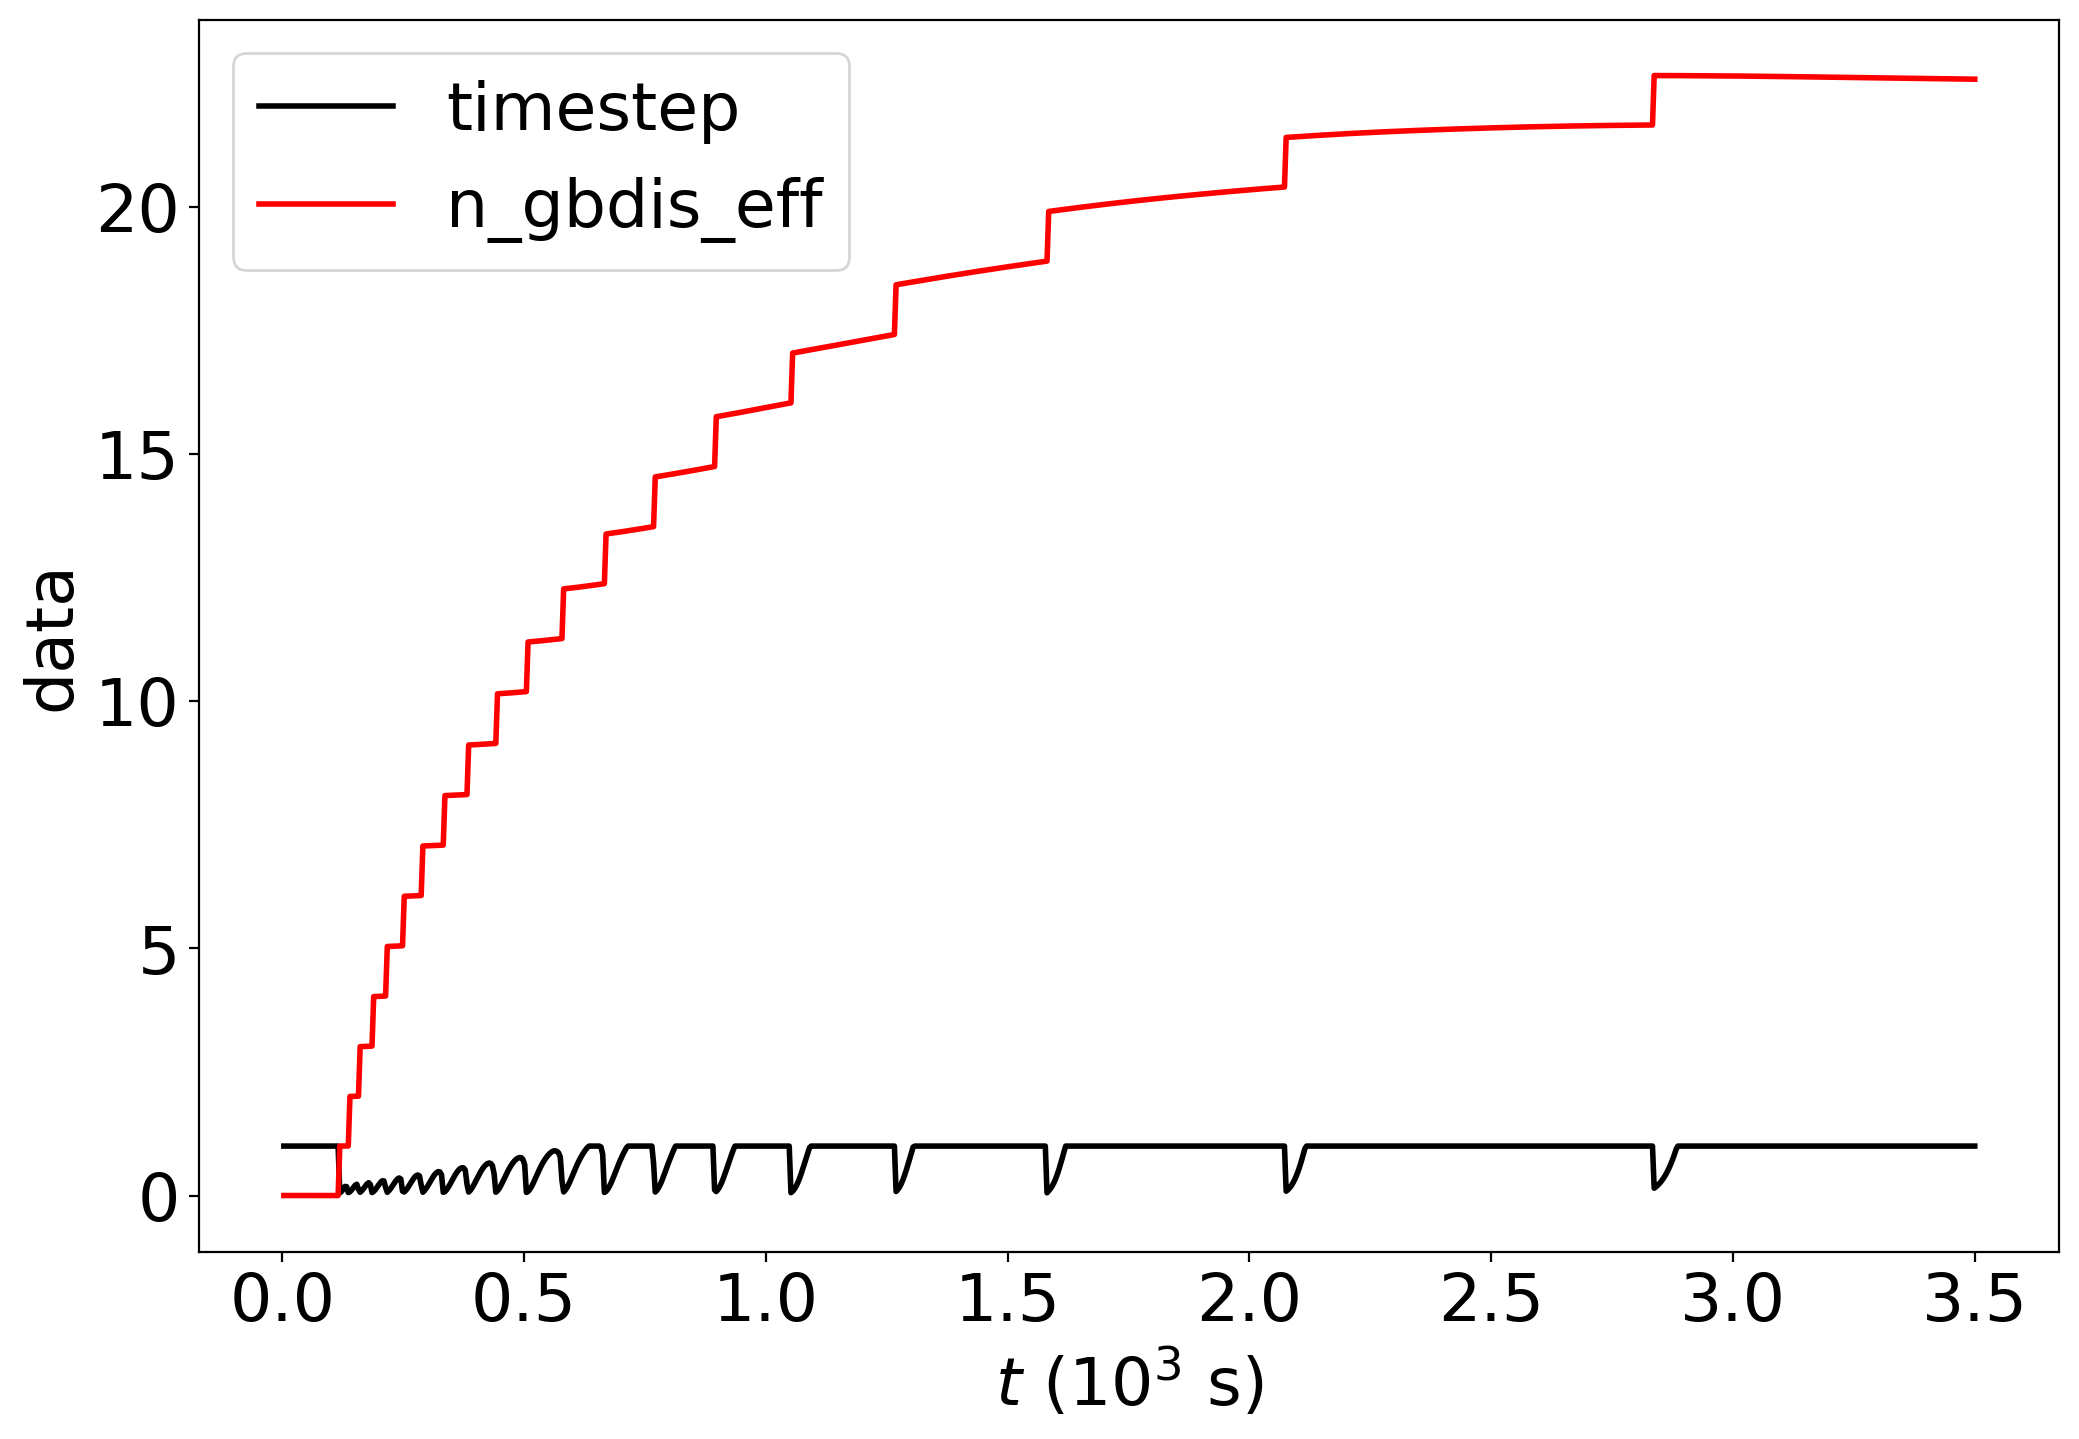

** Max. time step = 2441.406249999999, Median: 2441.406249999999


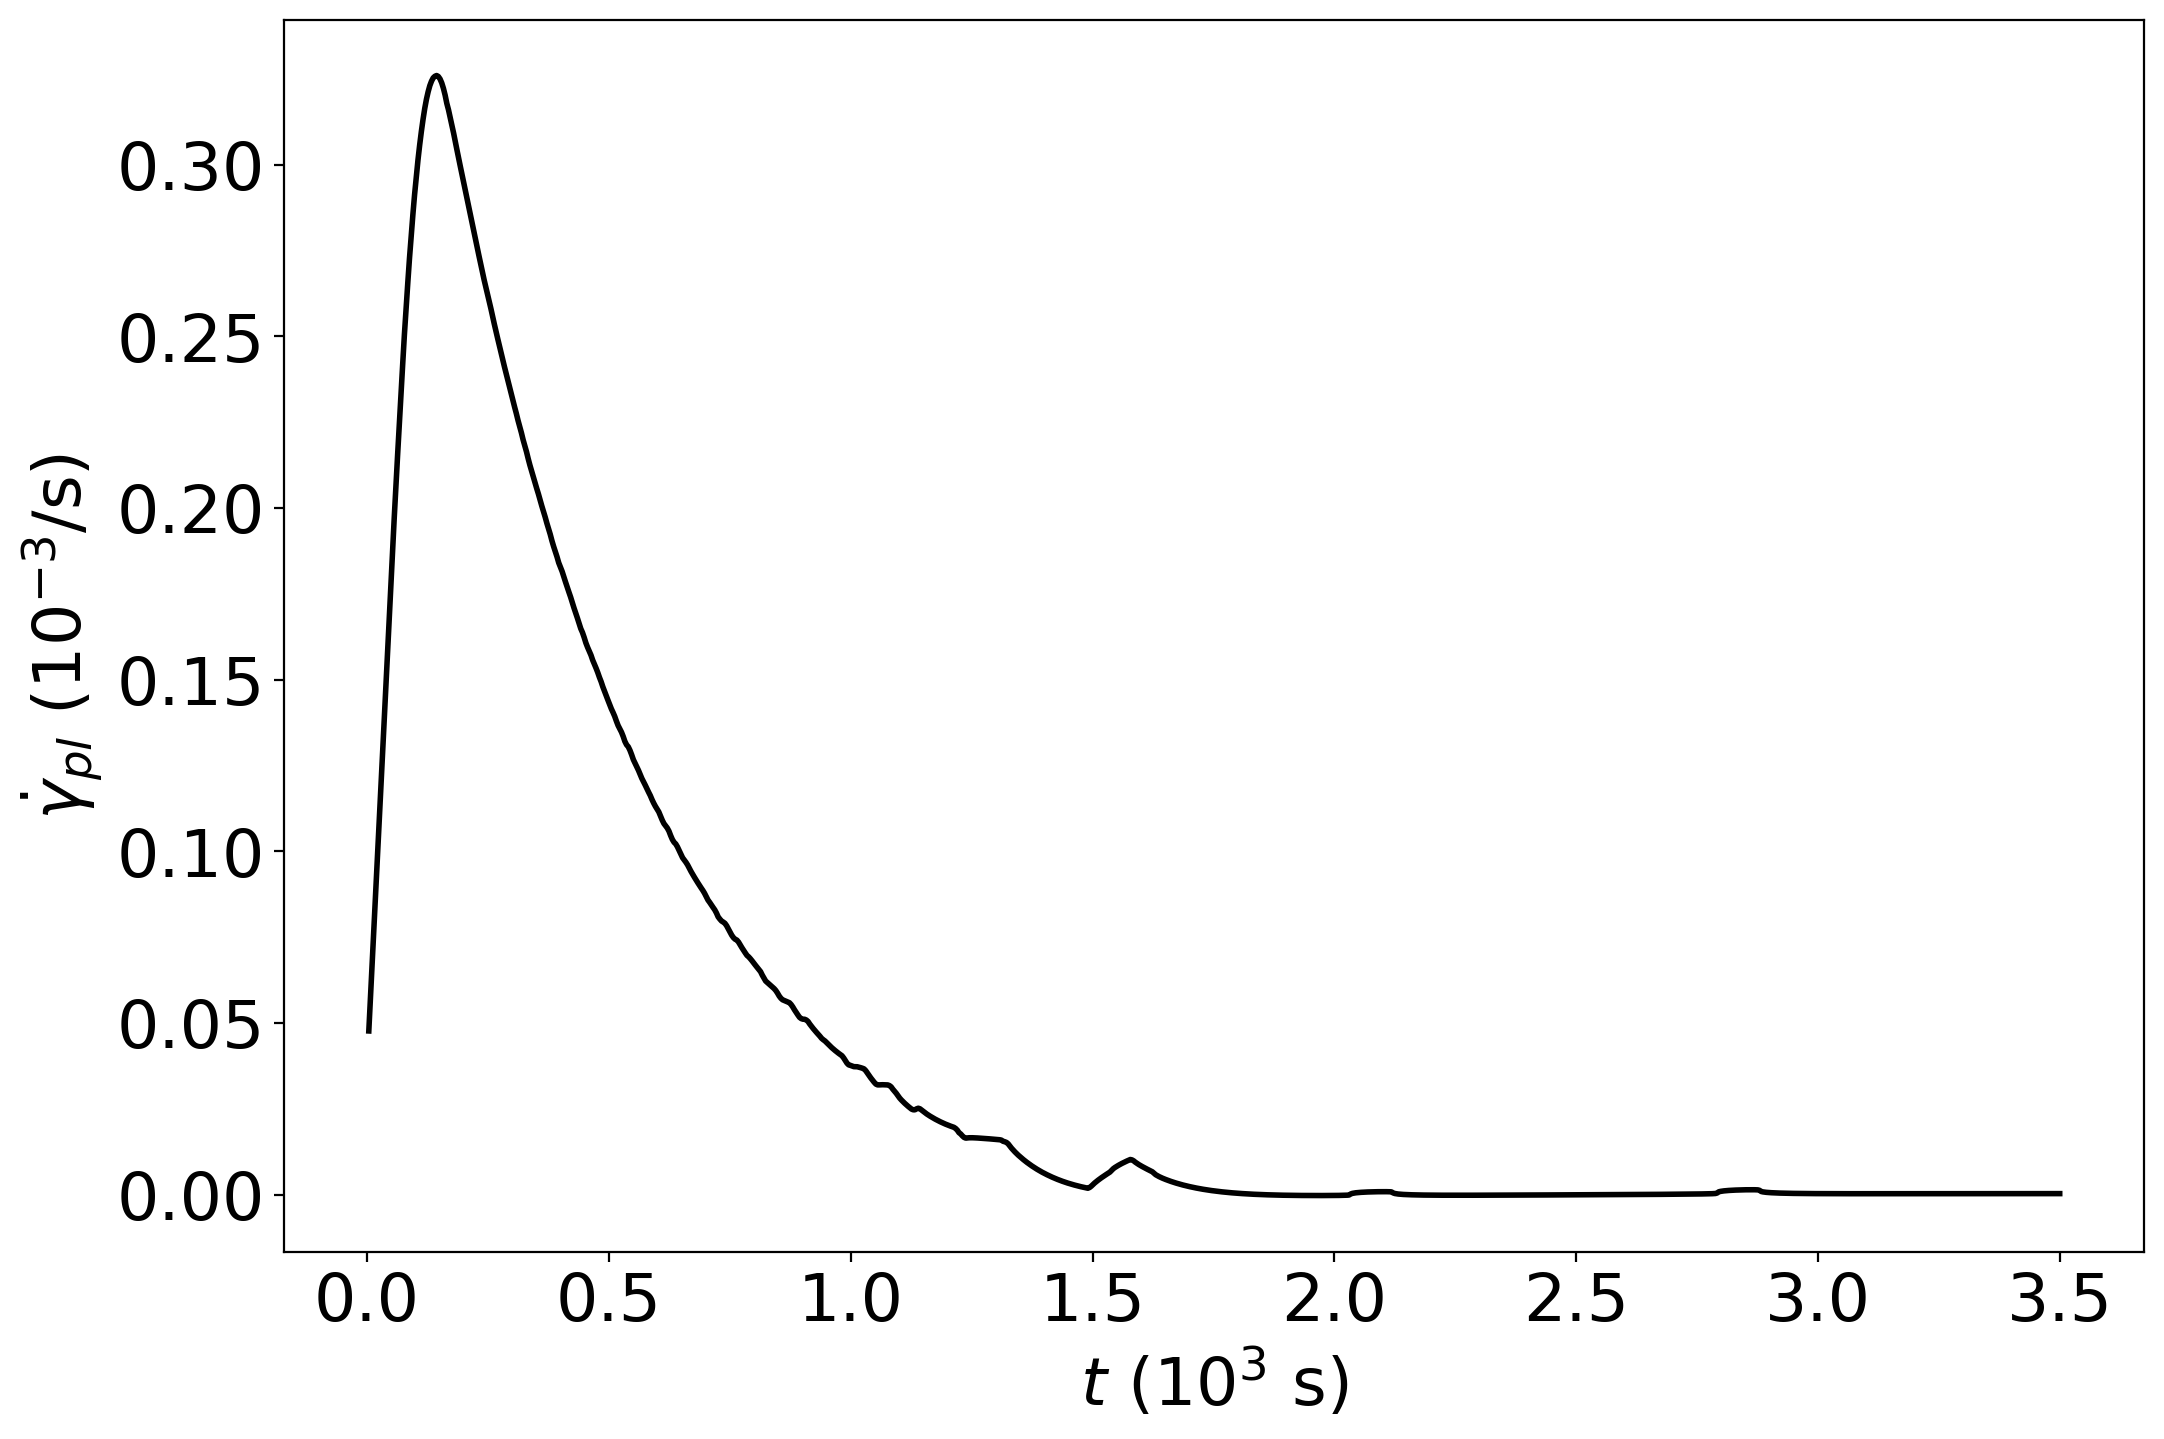

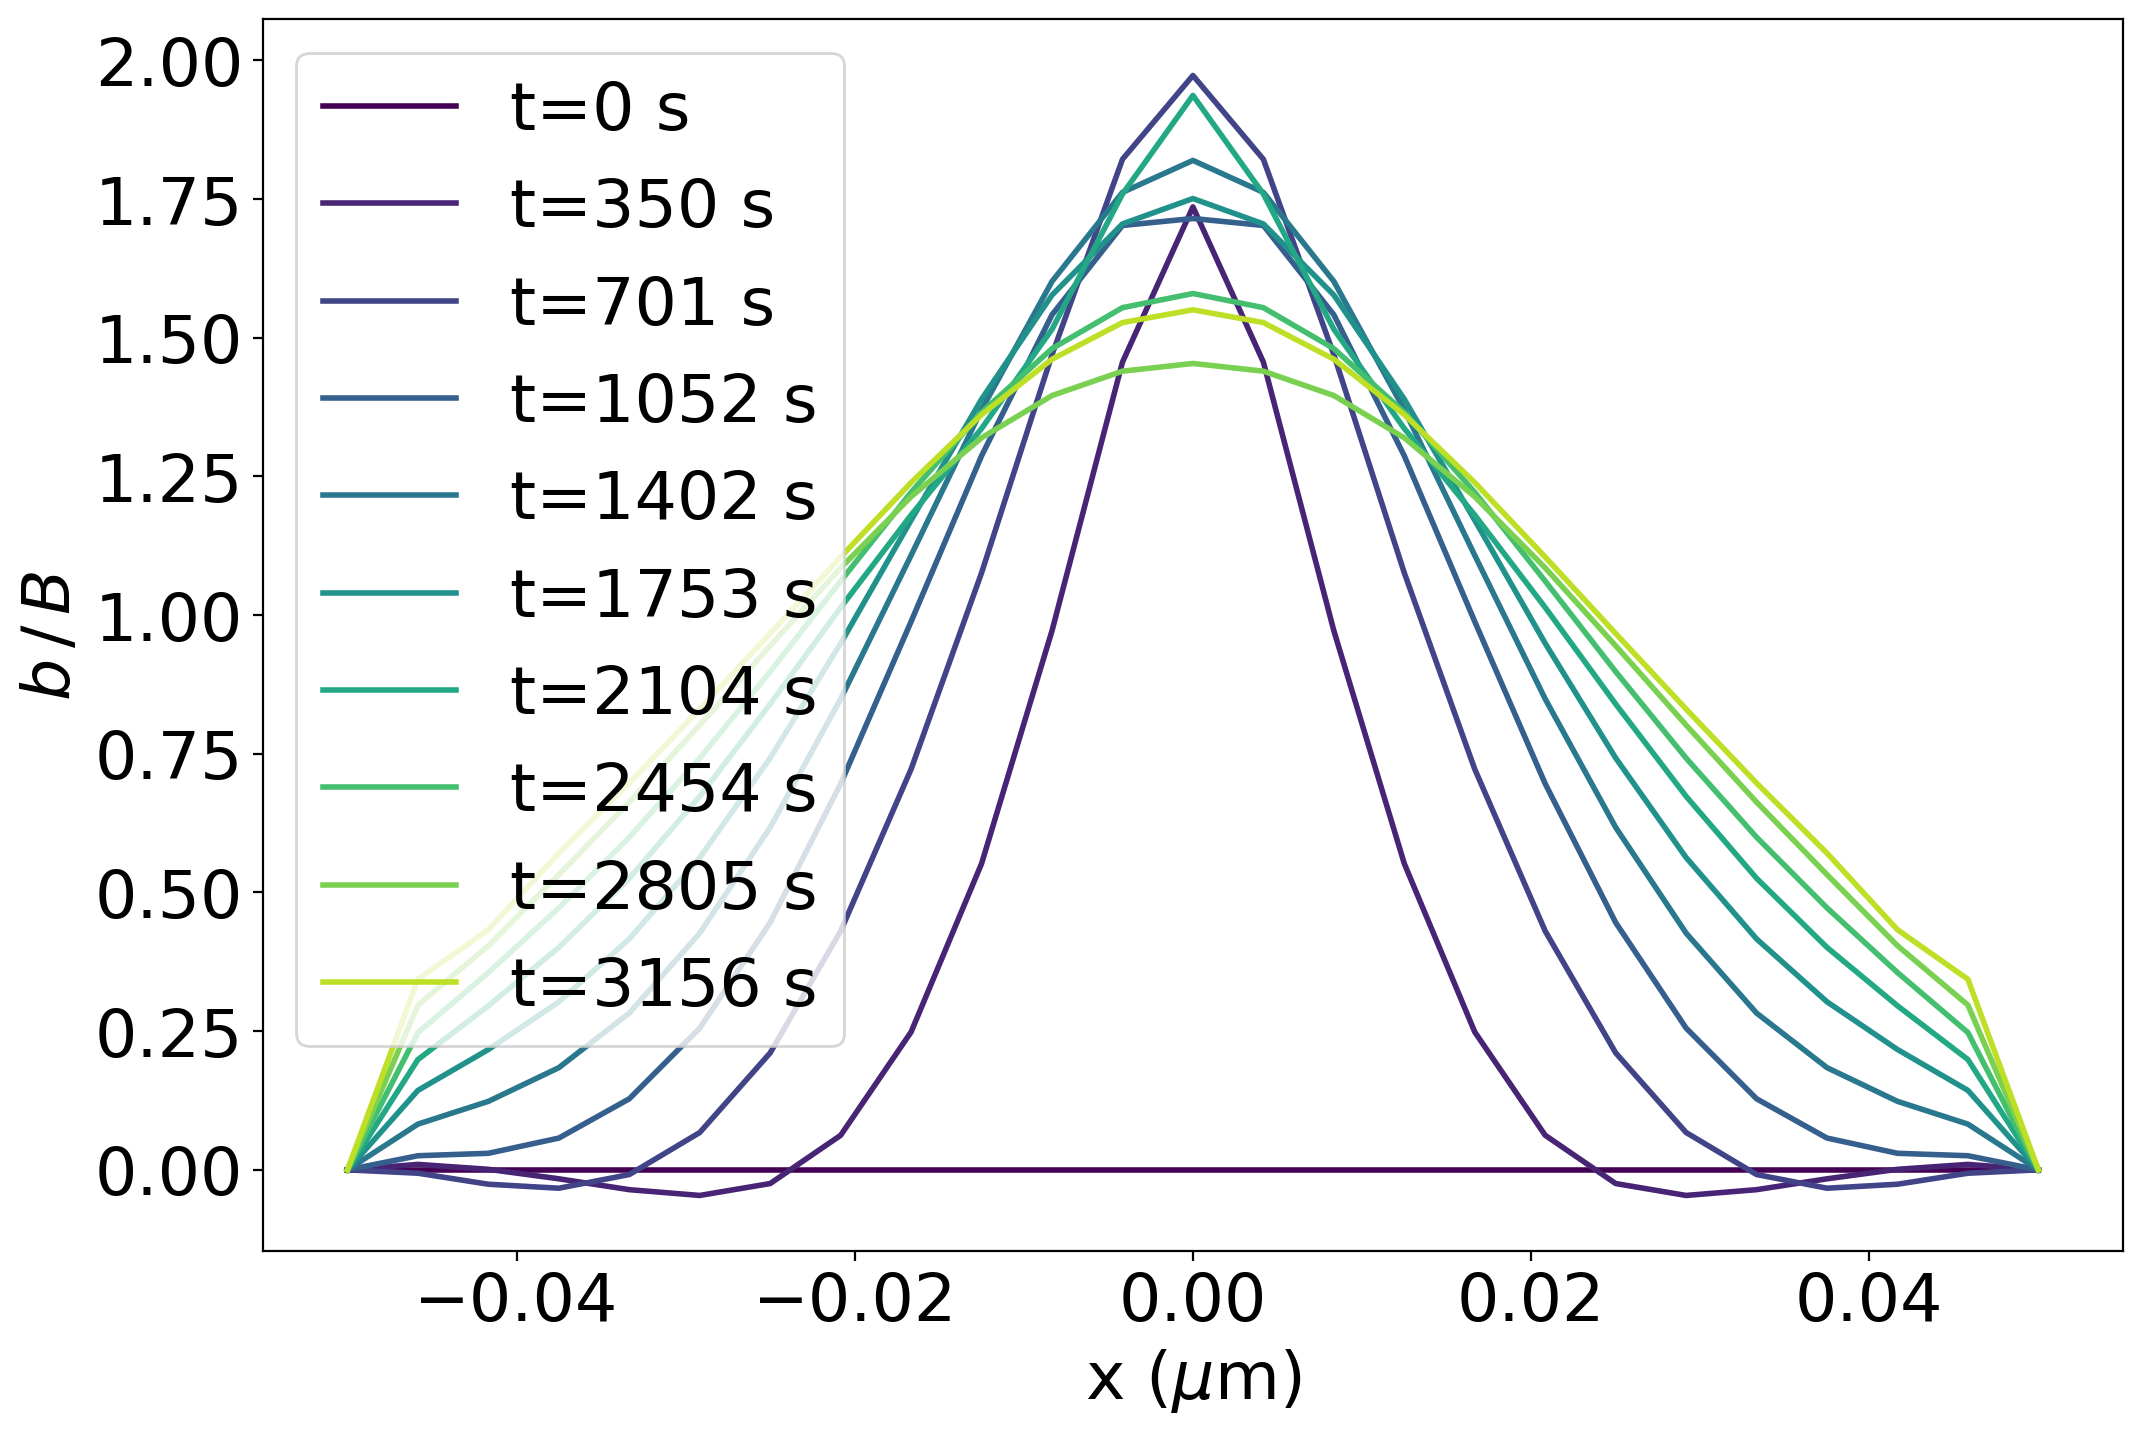

Data file with D=10.0, delta=0.1, dtmax=2441.4062499999995


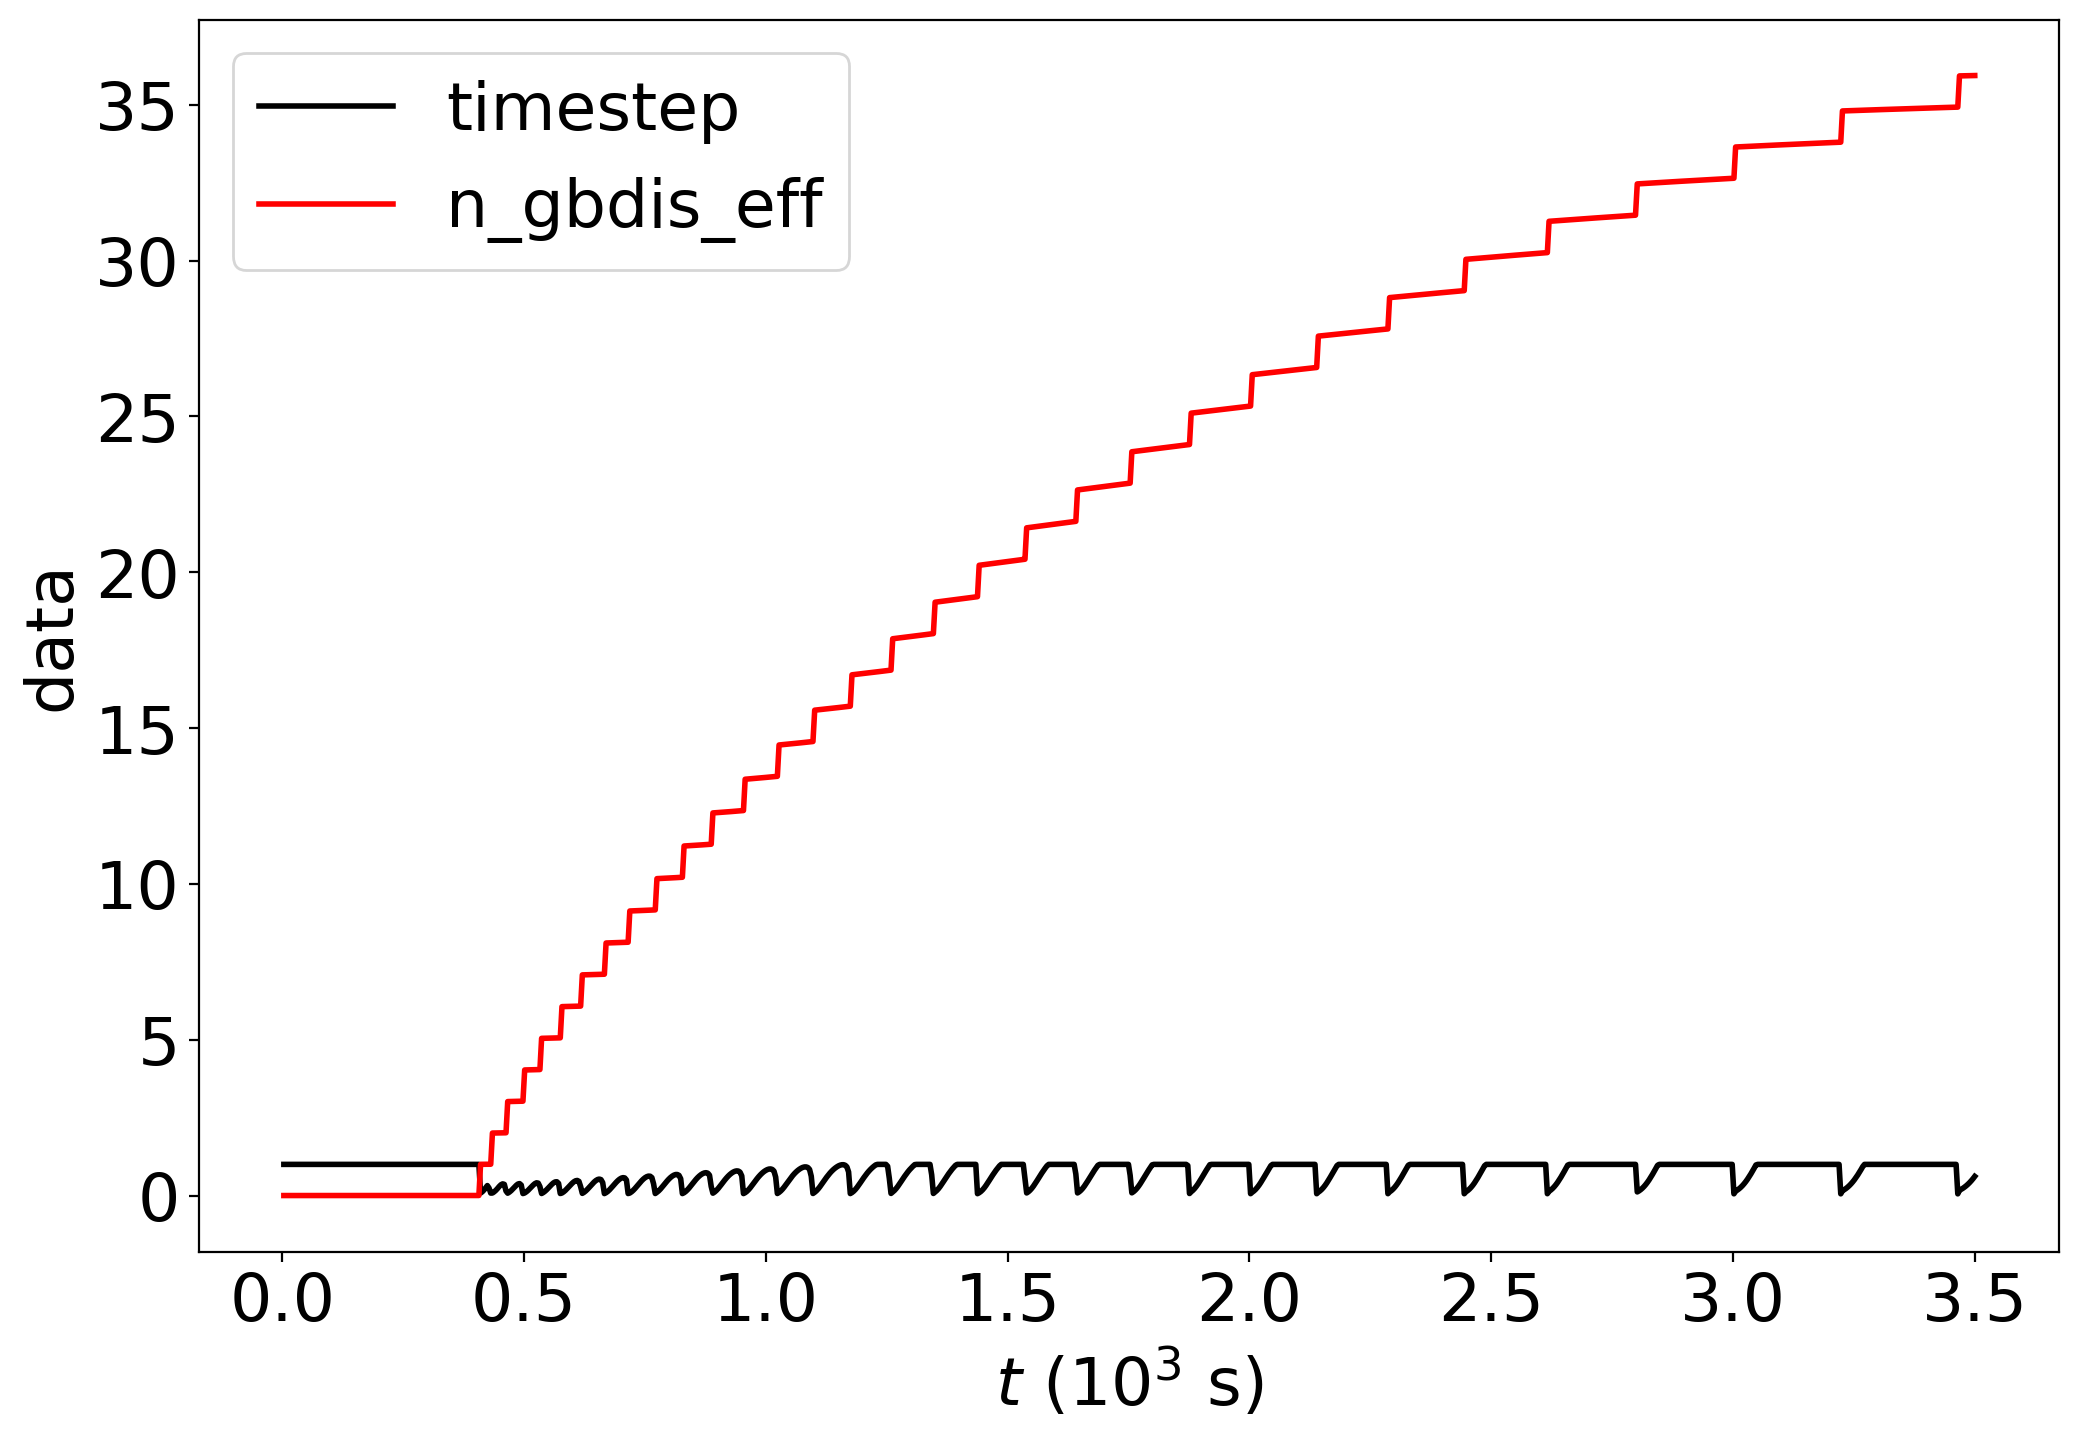

** Max. time step = 2441.406249999999, Median: 2441.406249999999


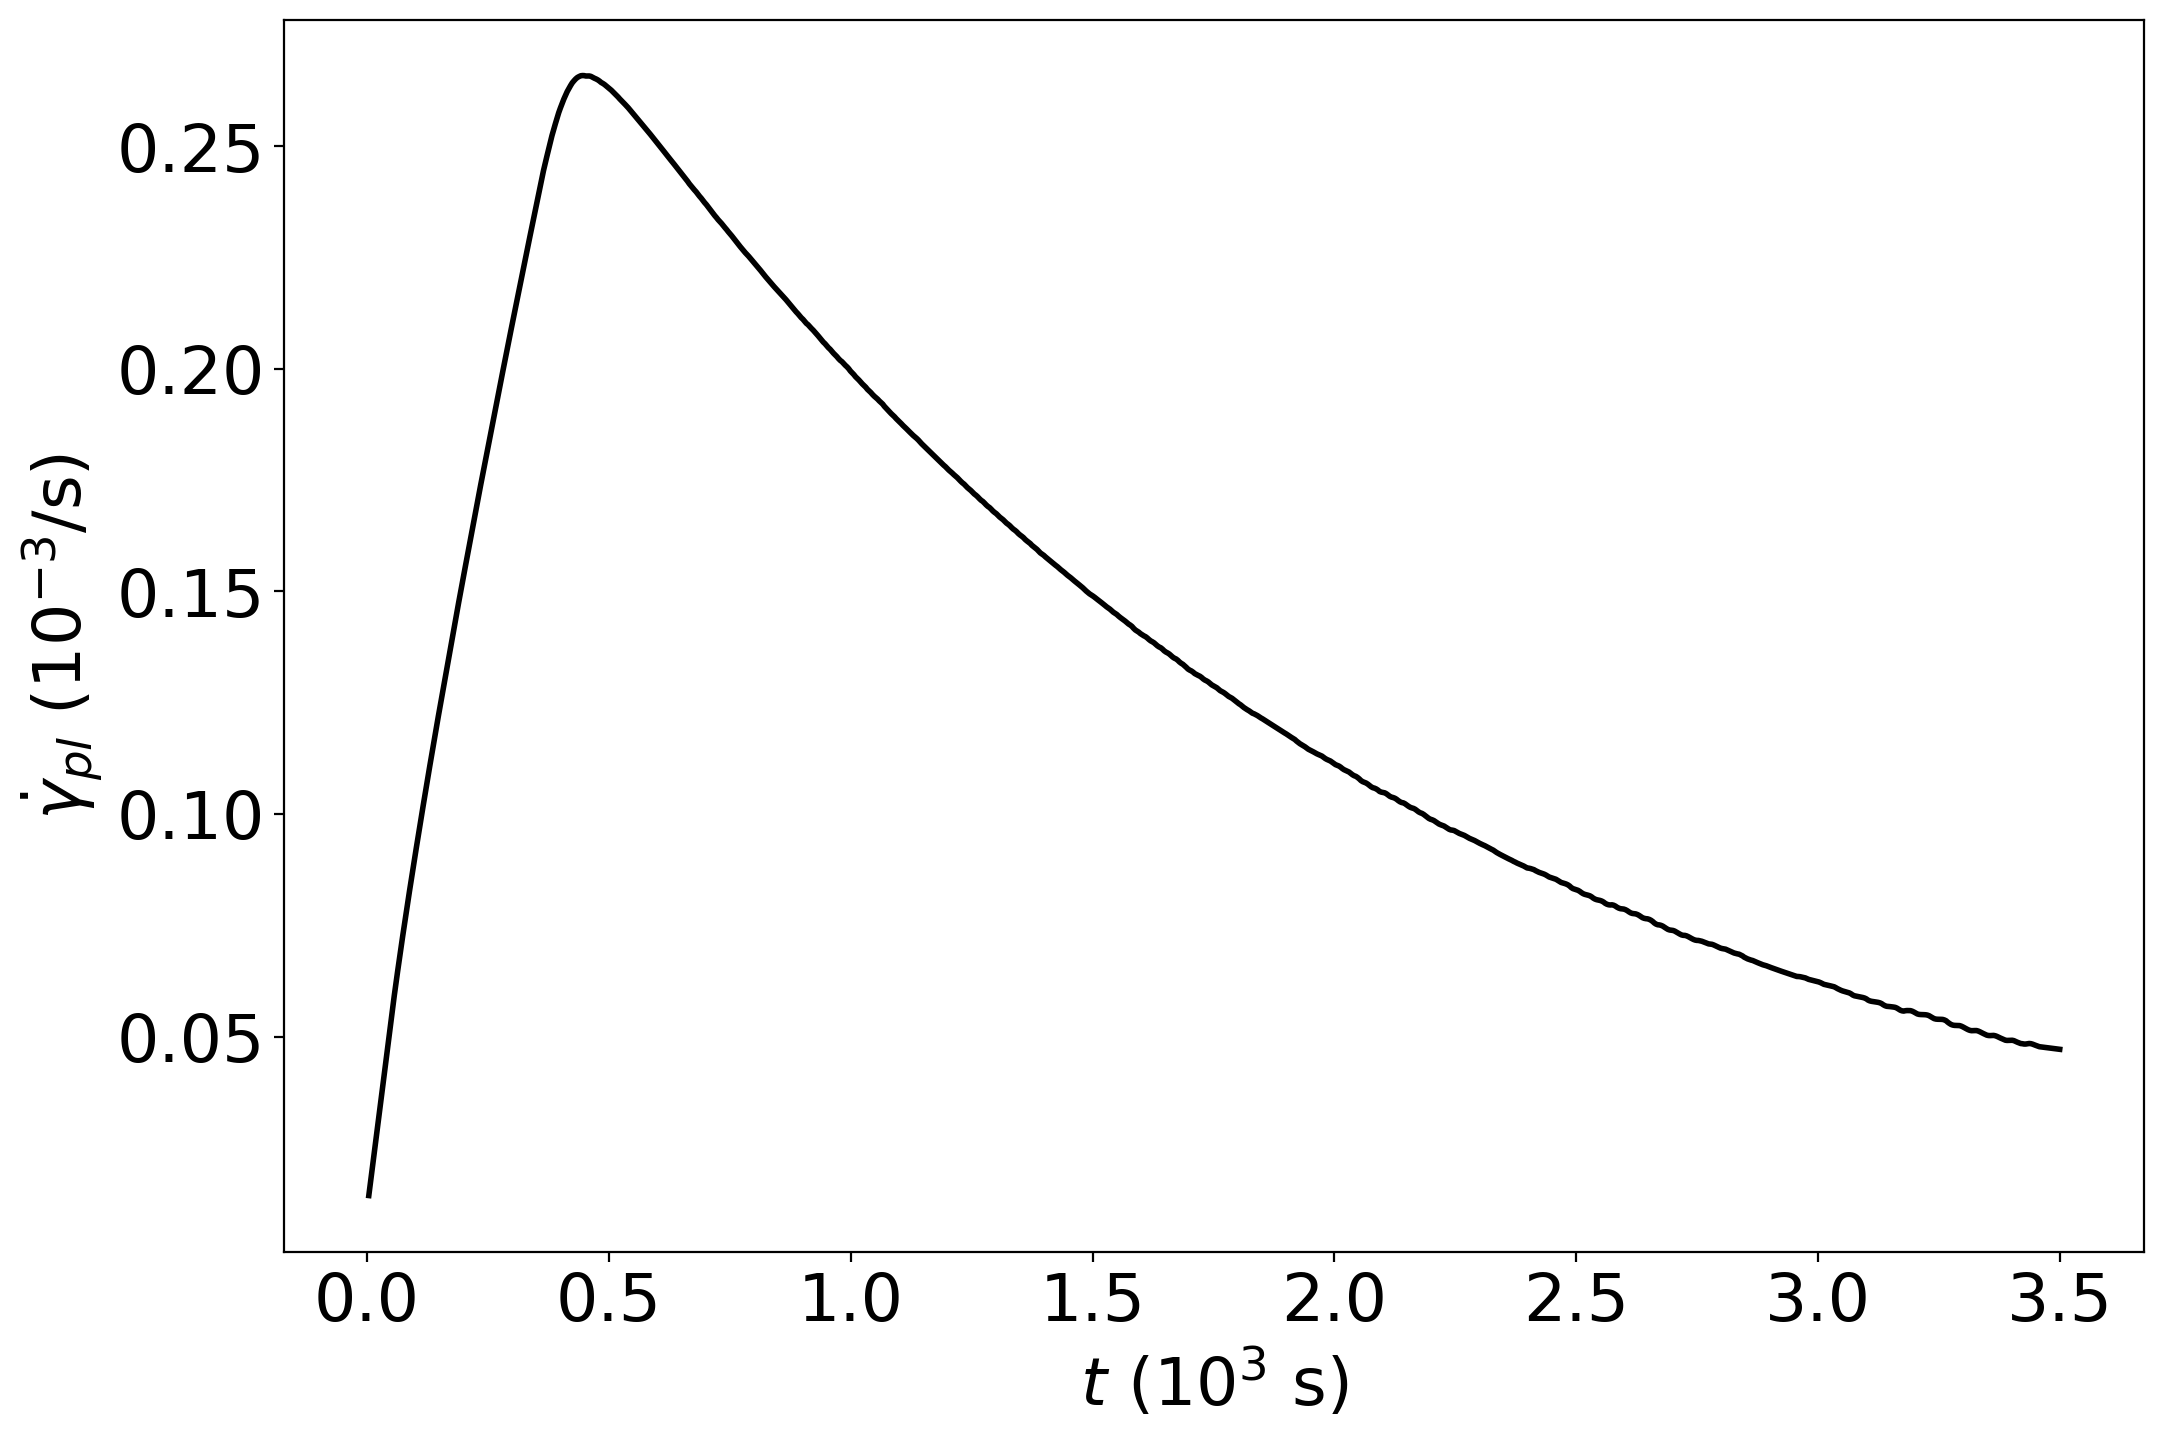

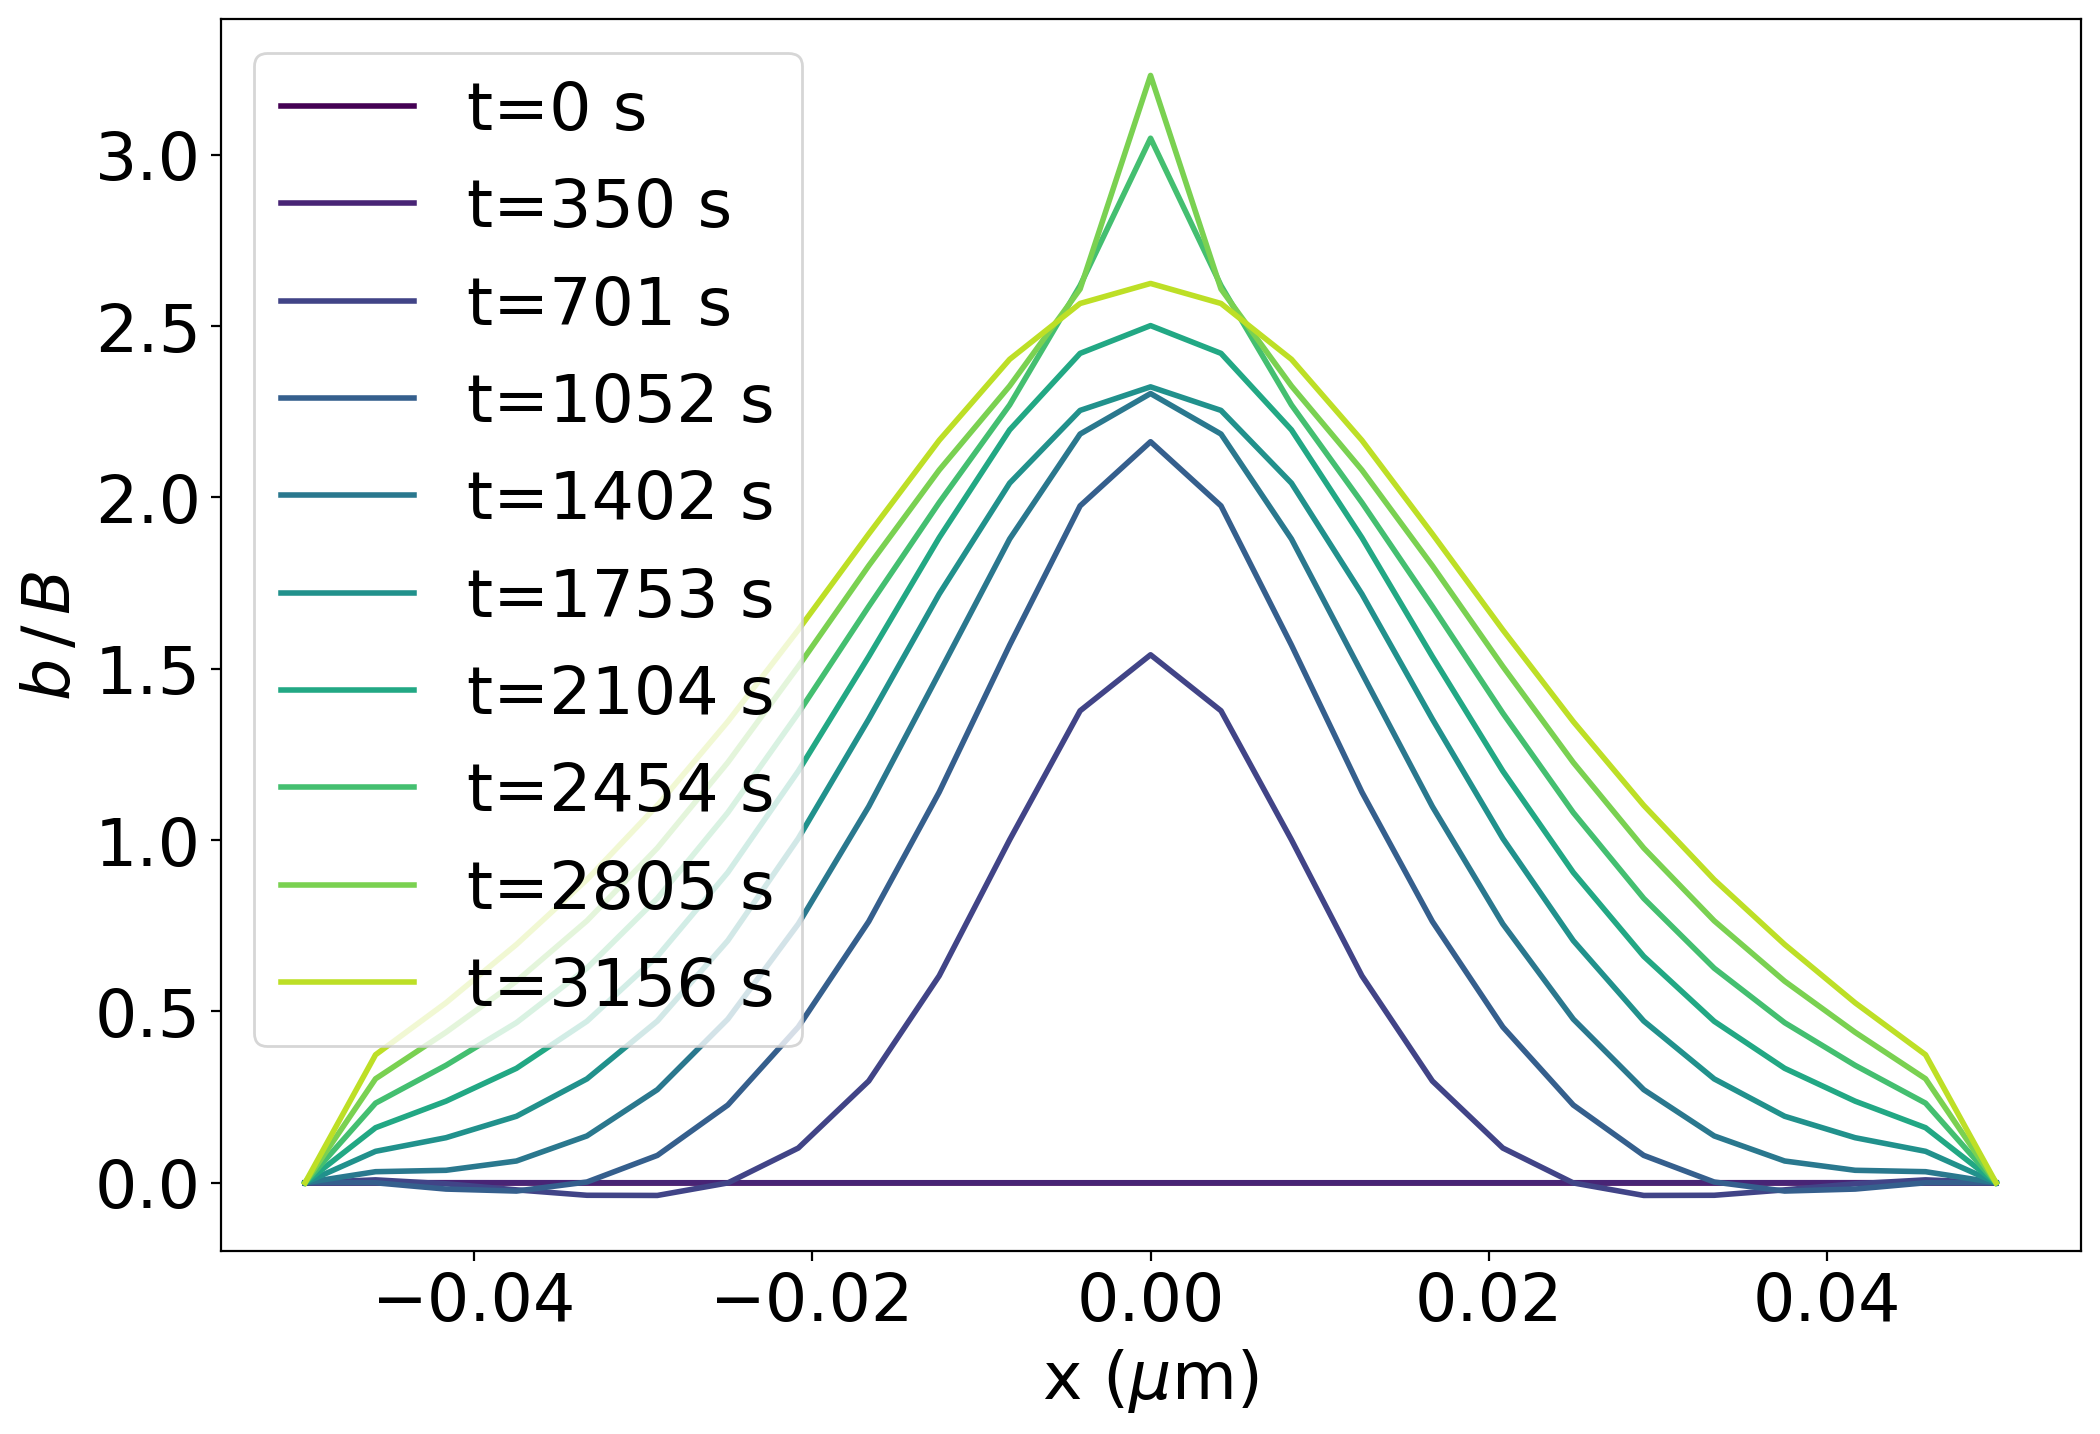

Data file with D=30.0, delta=0.1, dtmax=2441.4062499999995


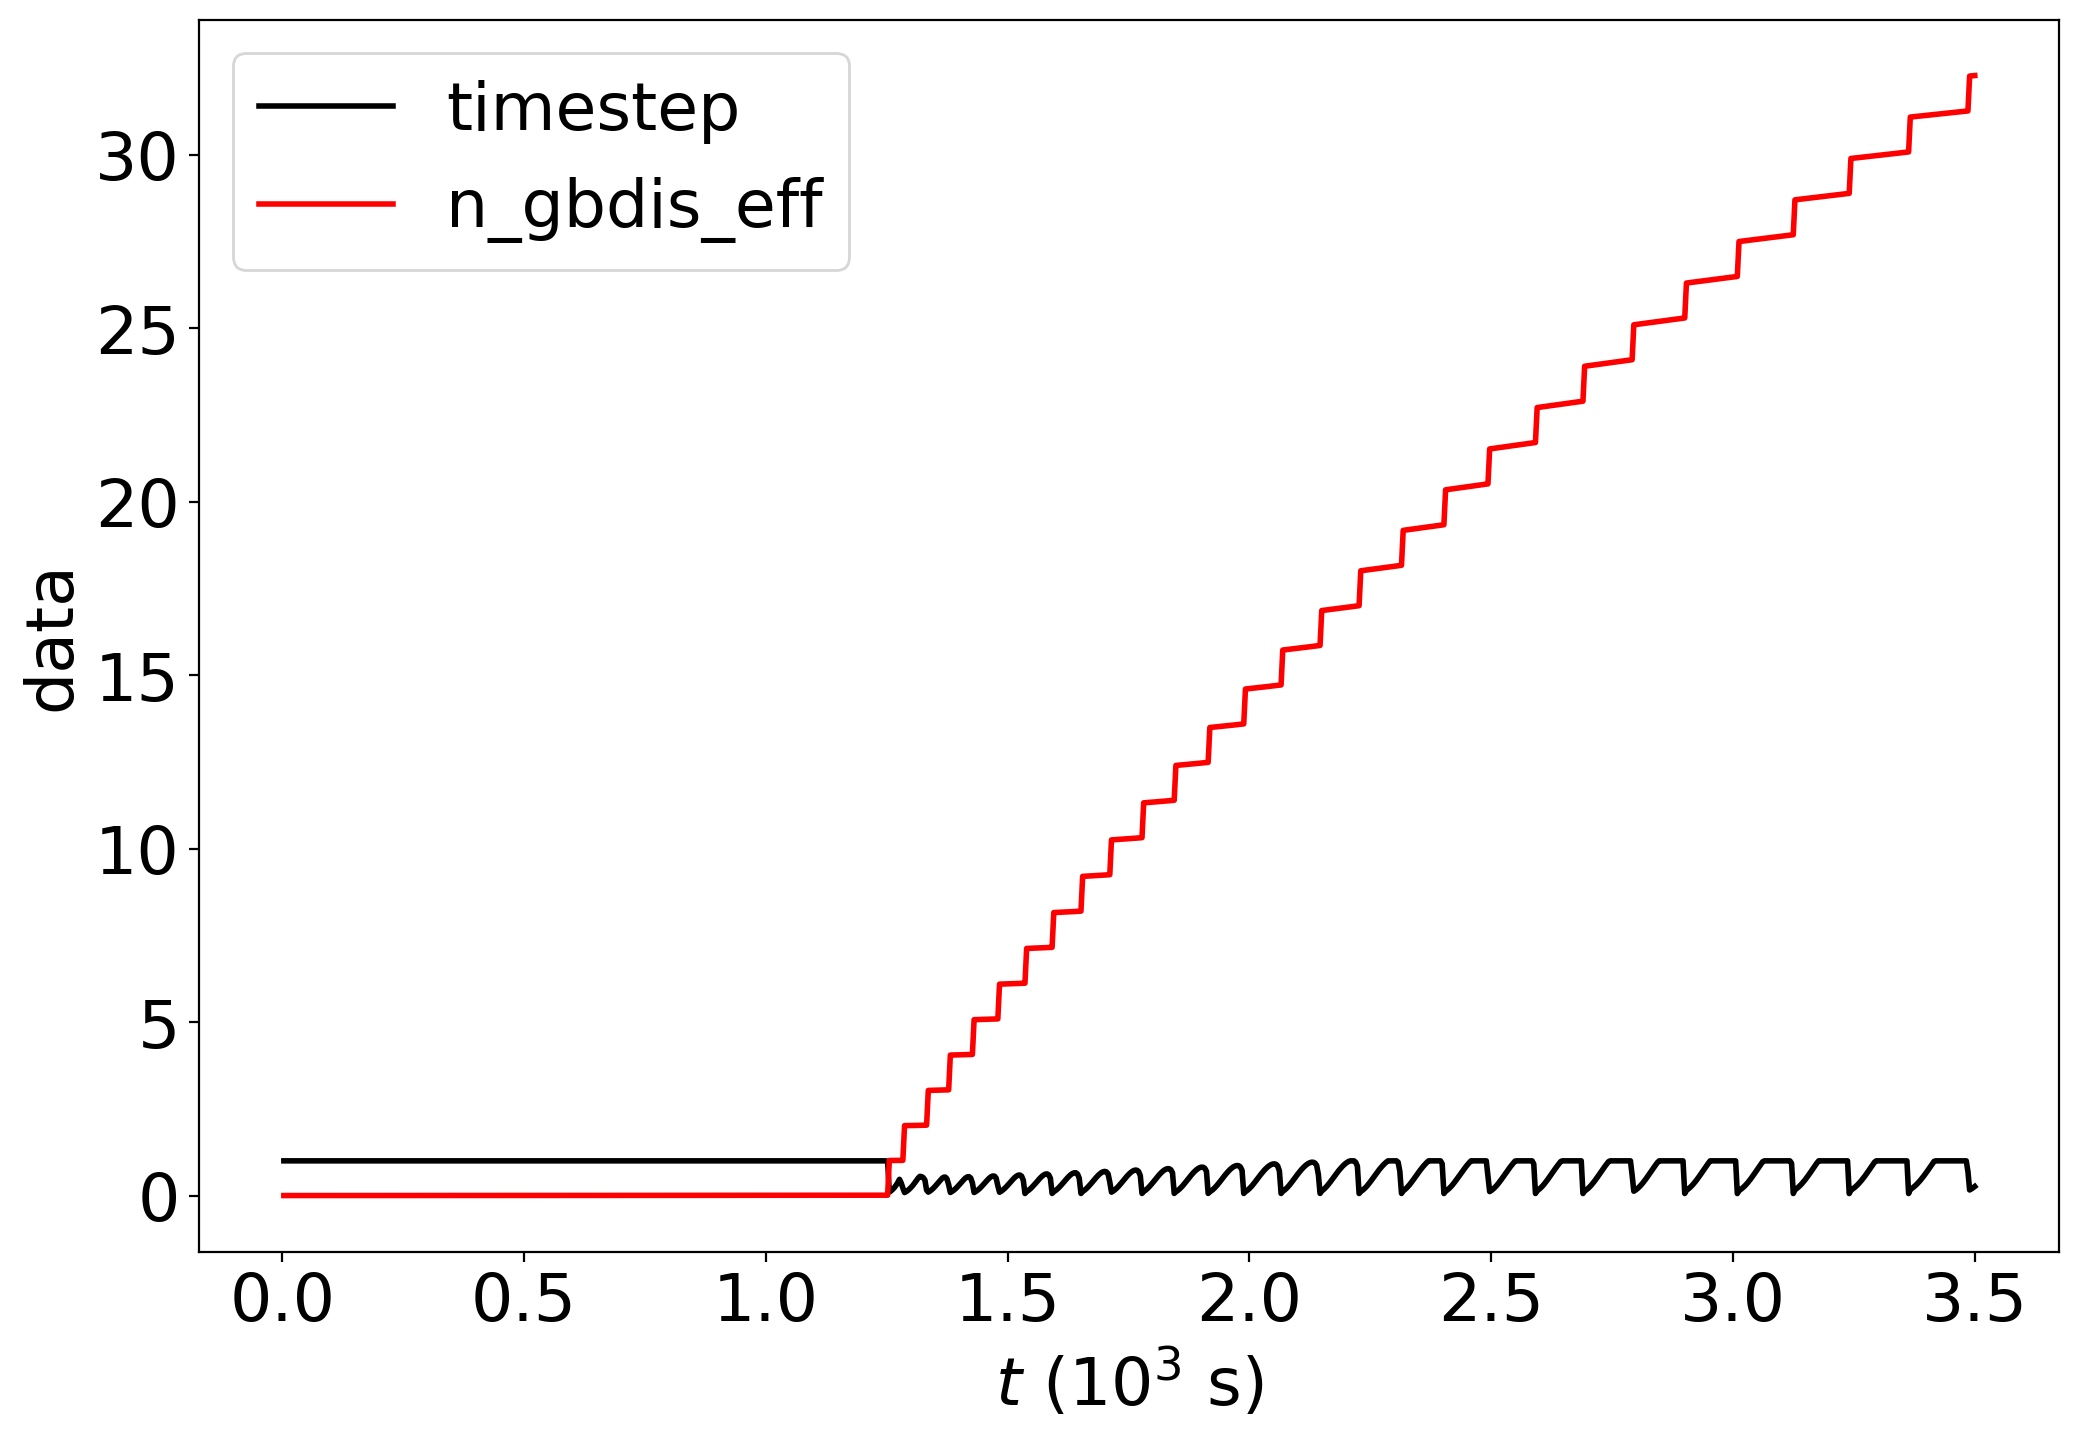

** Max. time step = 2441.406249999999, Median: 2441.406249999999


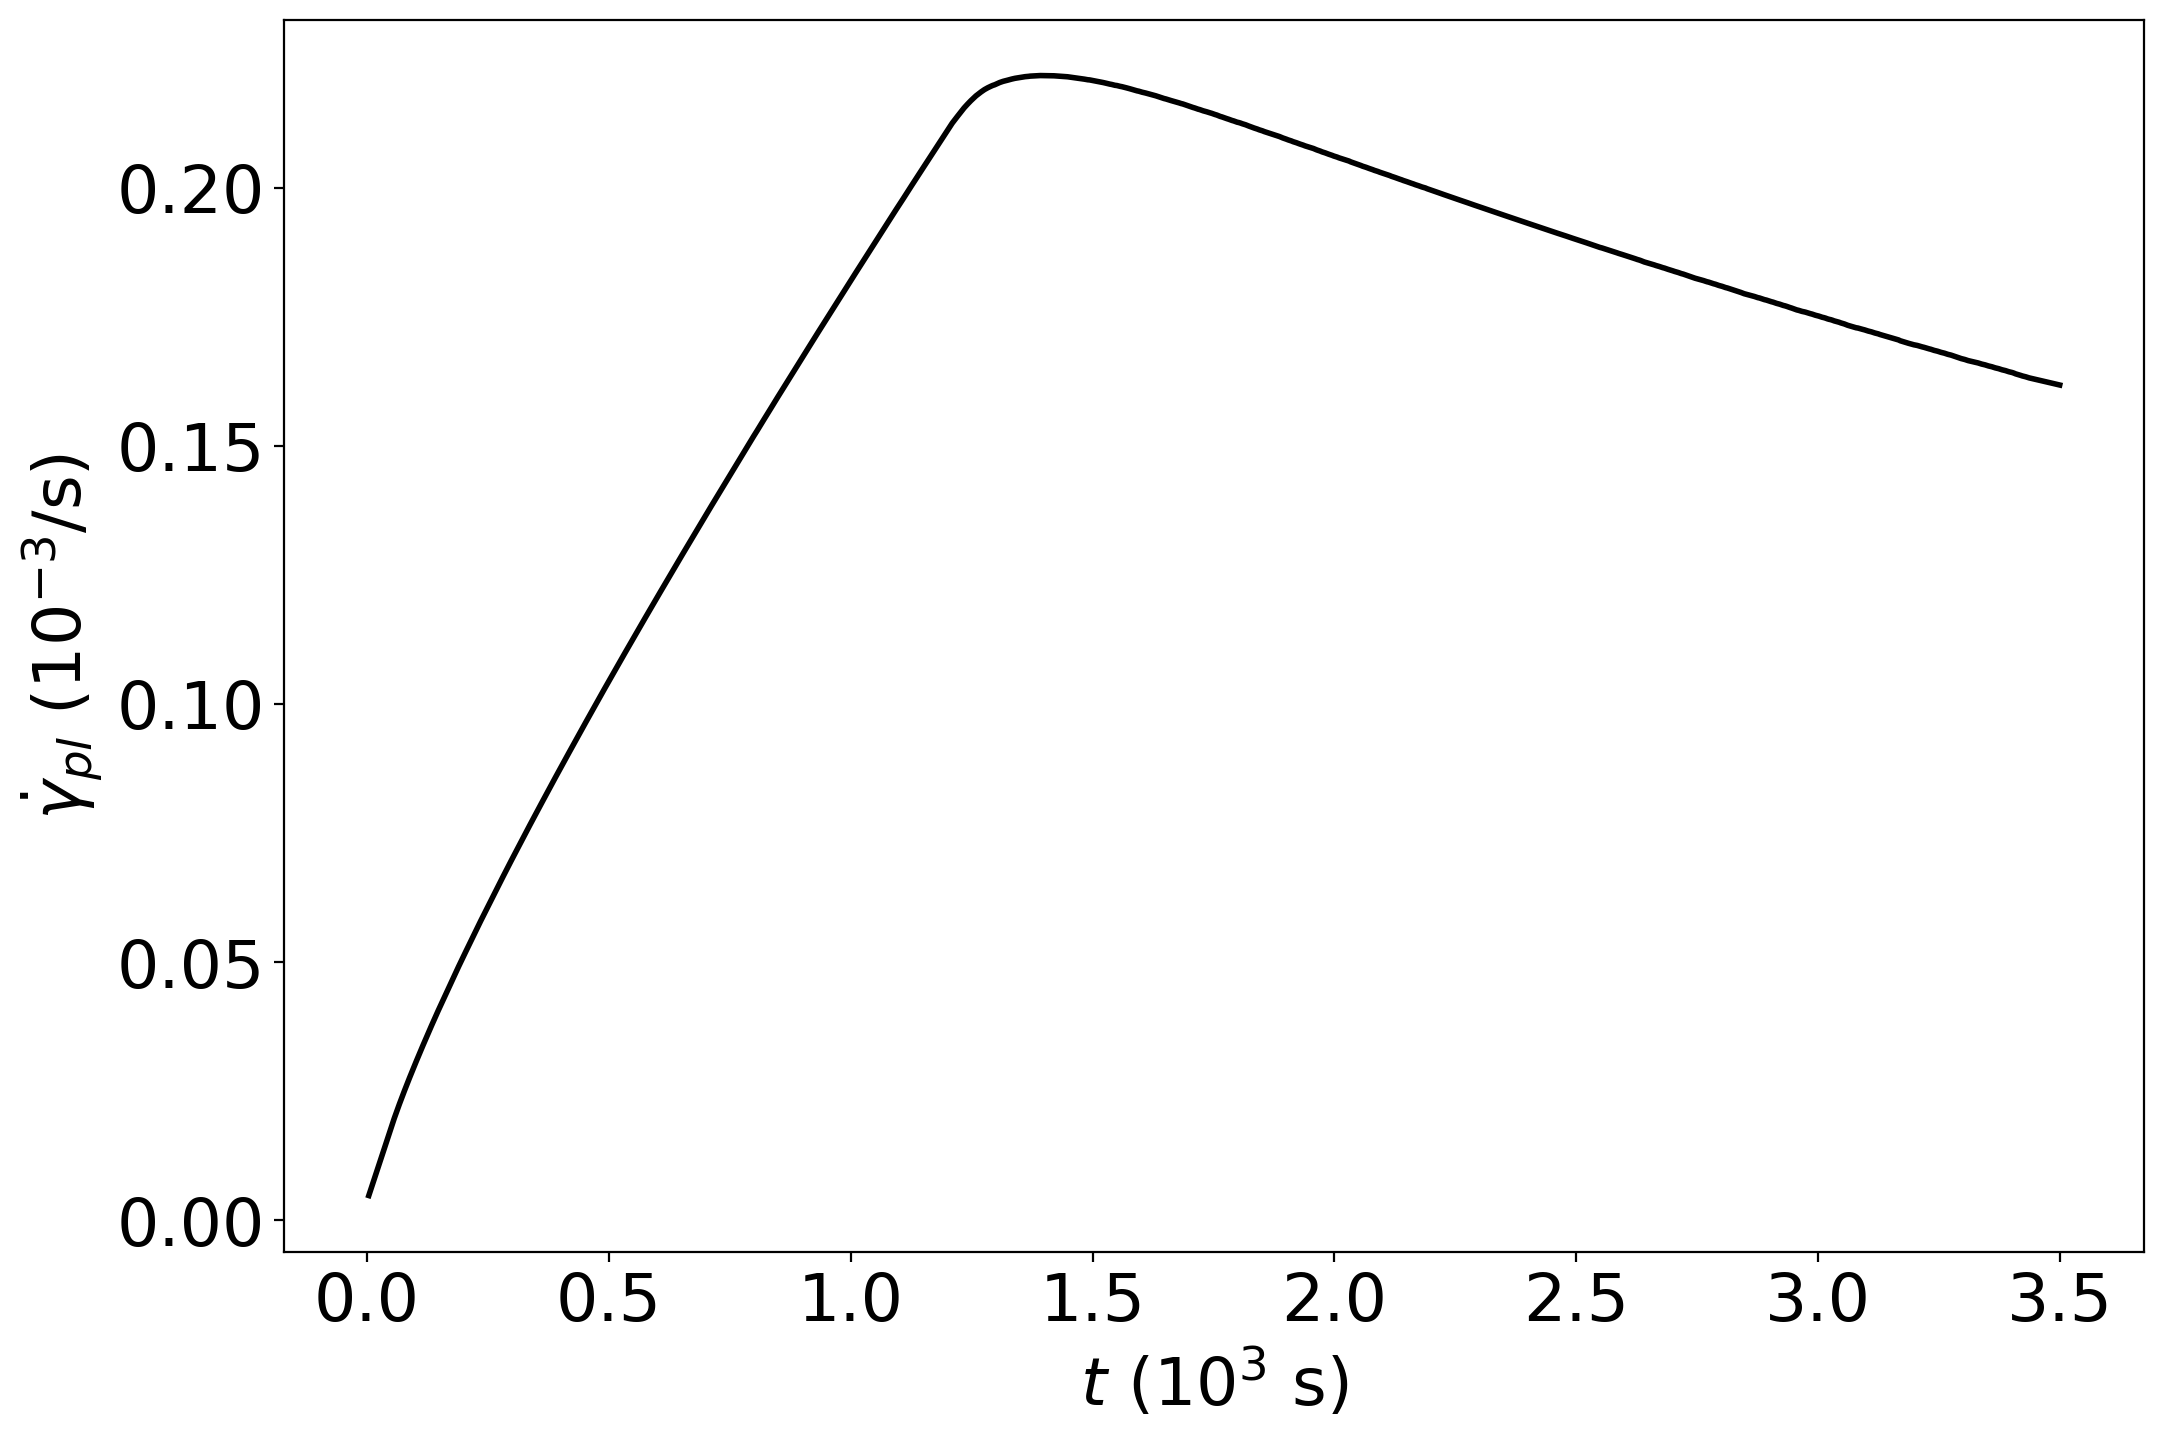

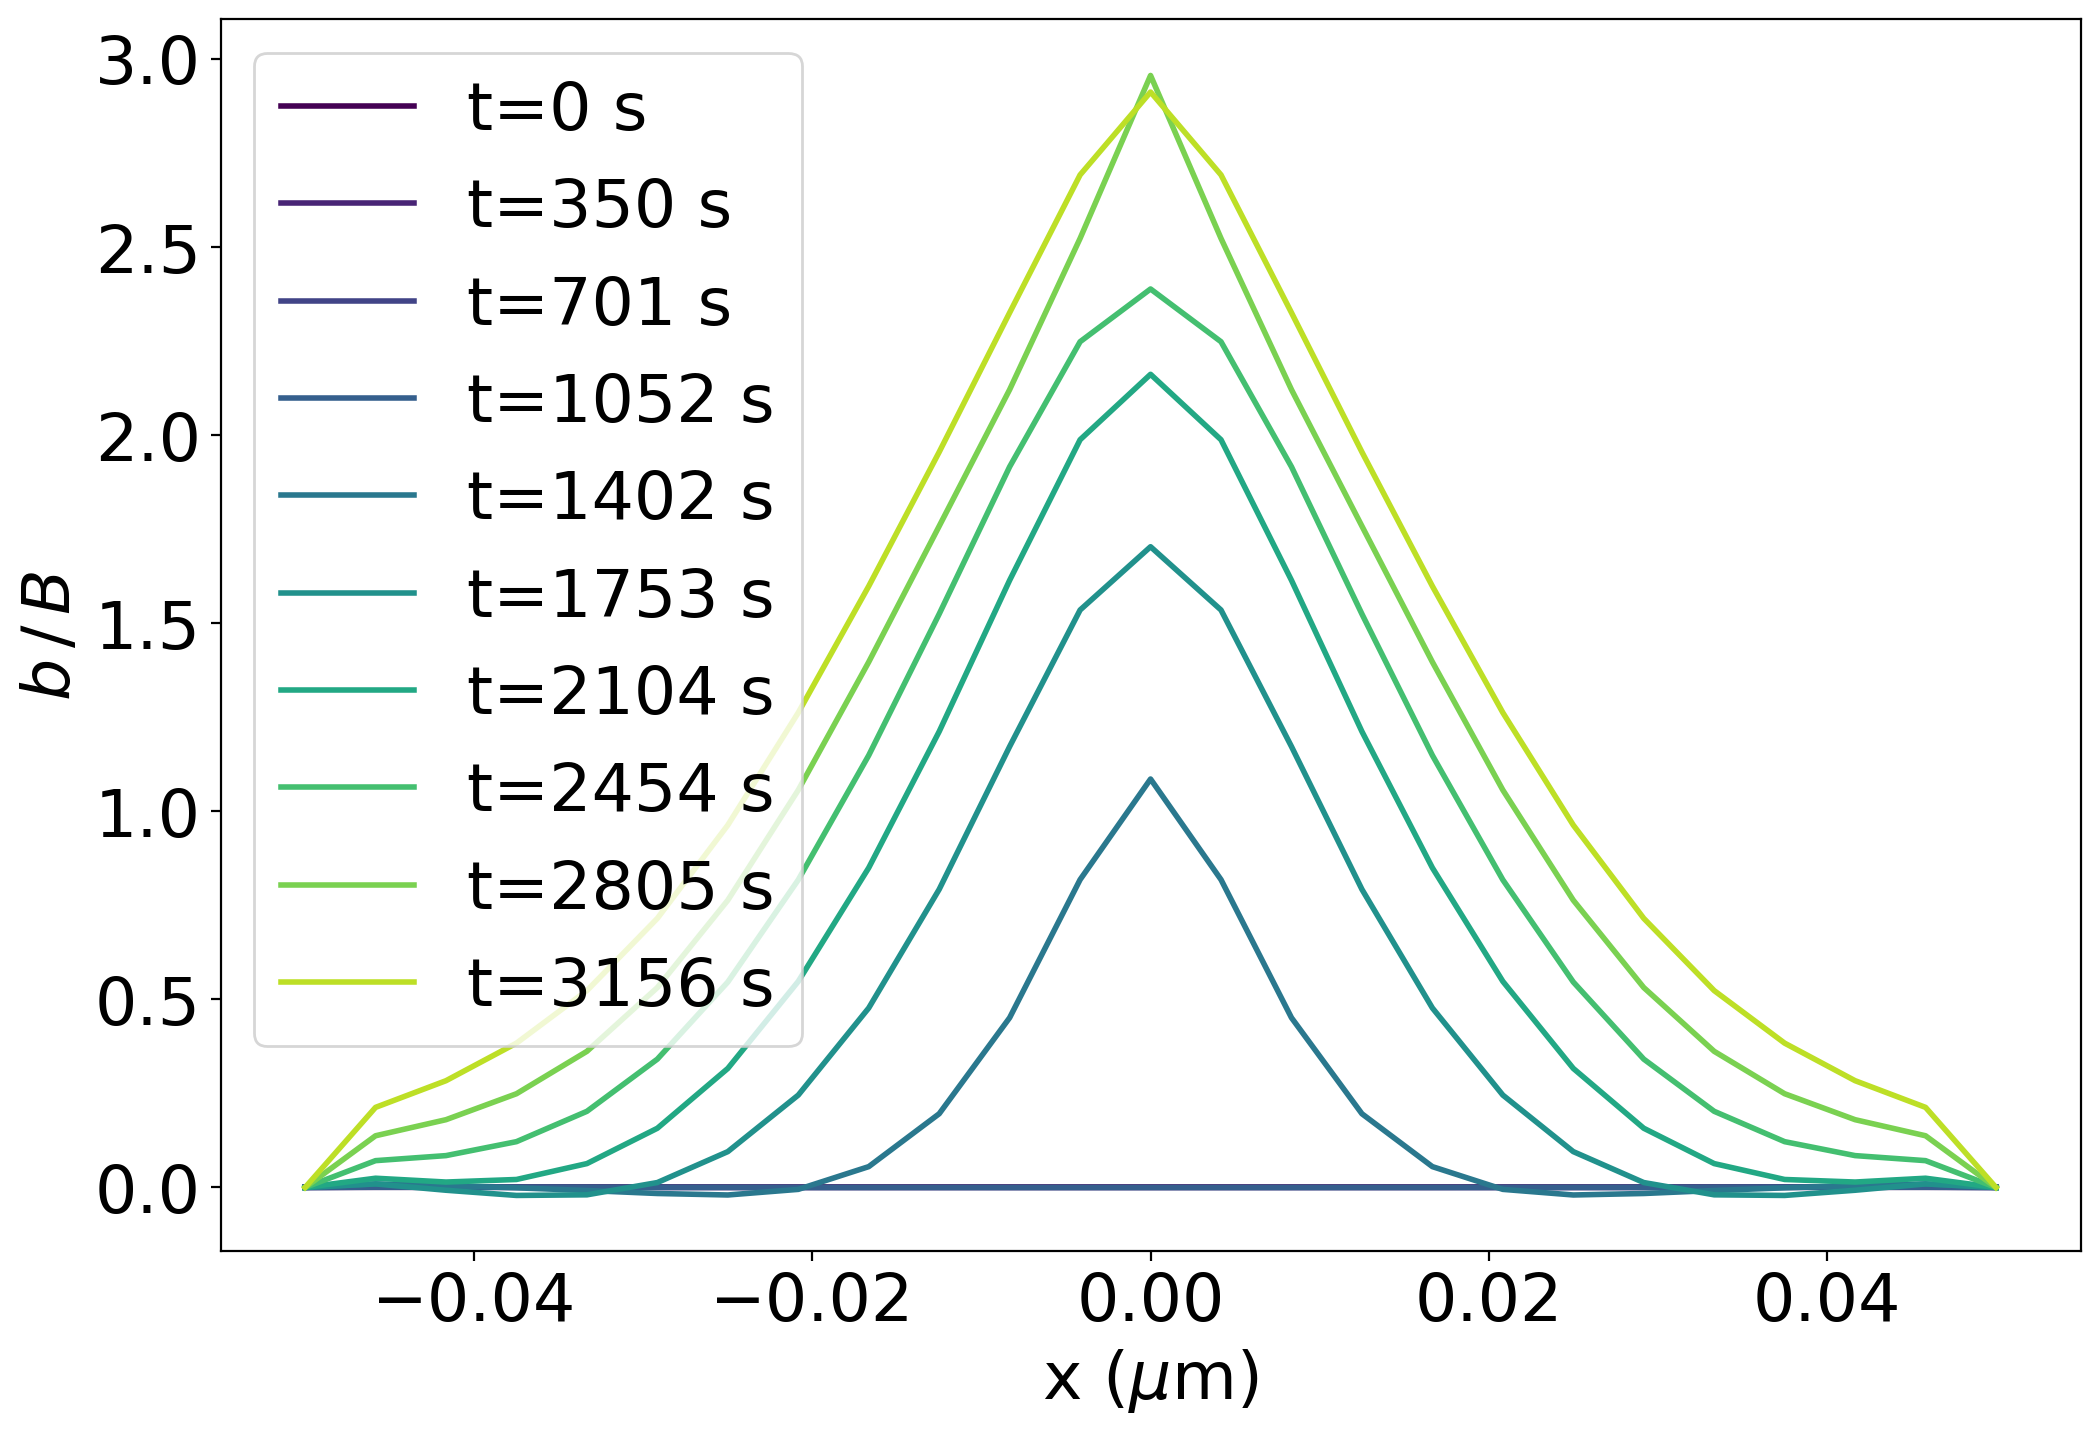

In [14]:
# read existing data from GDF5 files
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file=path+fname+".h5")
    print(f"Data file with D={gbdd.D2}, delta={gbdd.Dgp}, dtmax={gbdd.dtmax}")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    #gbdd.plot_time_series('max_bdot')
    #gbdd.plot_time_series('plast_slip_rate')
    gbdd.plot_time_series('psr_av')
    #gbdd.plot_field('displacement')
    gbdd.plot_field('bfield')
    nit[i] = gbdd.nout
    gs_list[i] = gbdd.D2
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
                          

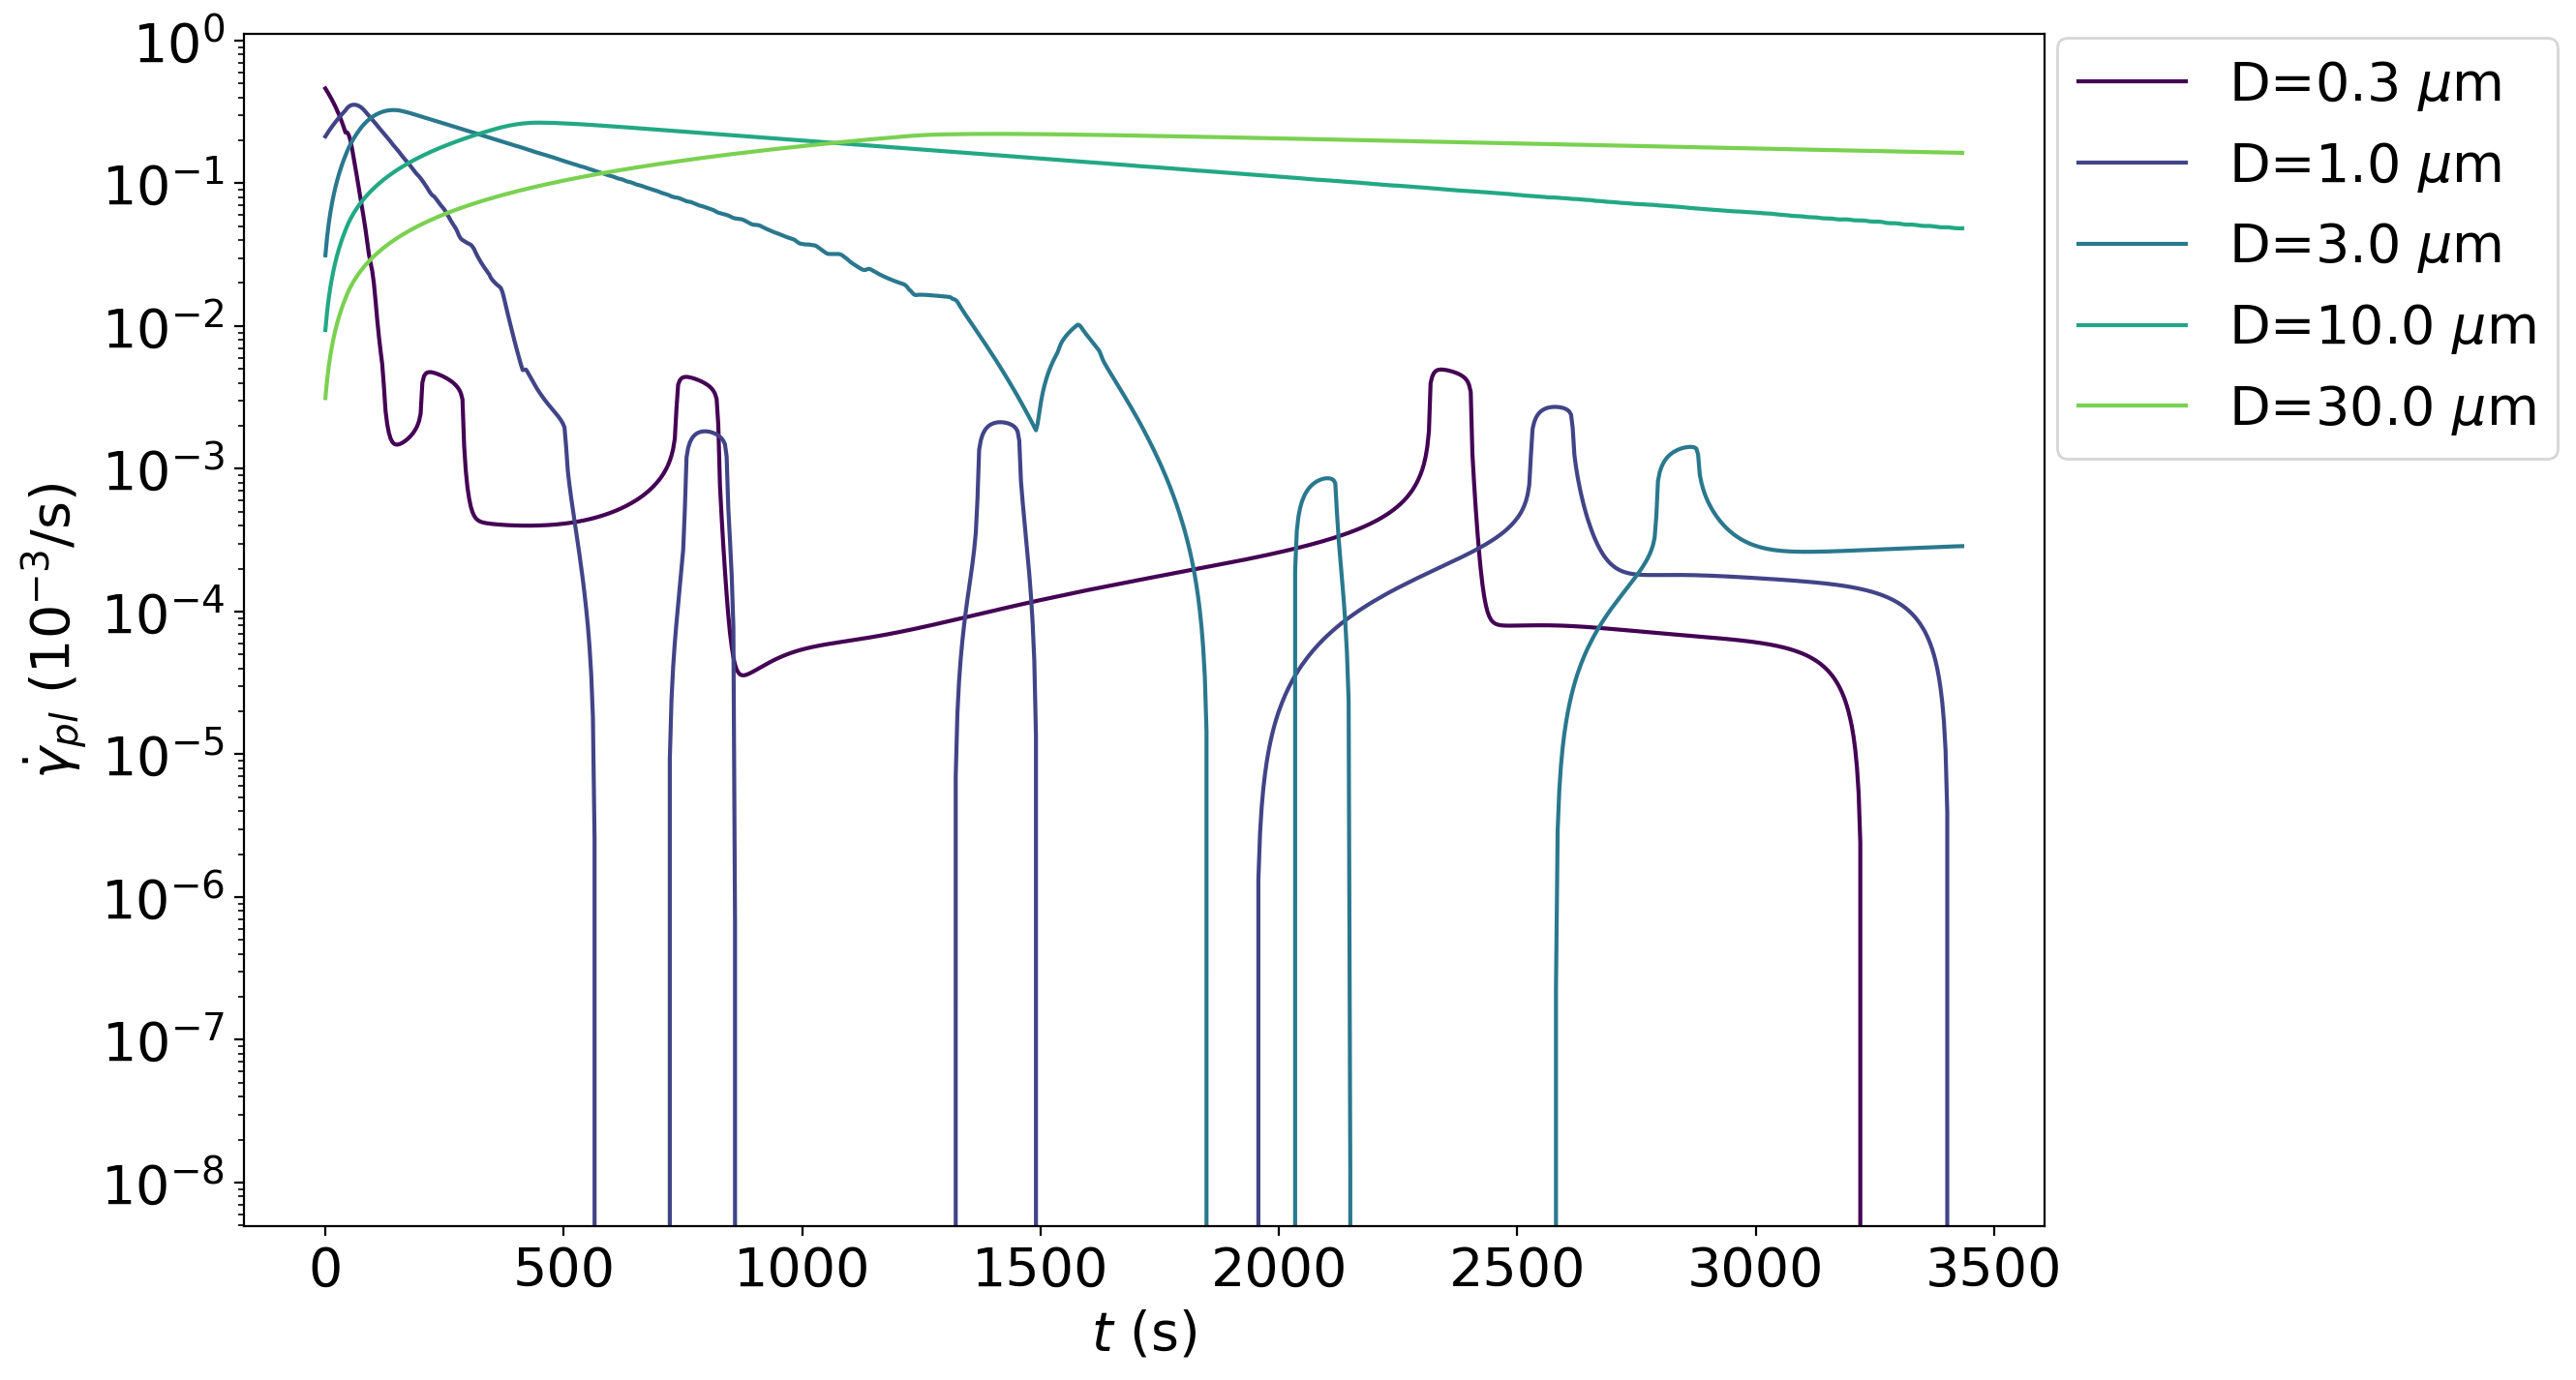

In [15]:
plt.rcParams["font.size"] = 20

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.semilogy(sim_time[i, :nit[i]-20]*1.e-6,
             psr_av[i, :nit[i]-20]*1.e9,
             marker="none",
             linestyle="-",
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"D={gs_list[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()

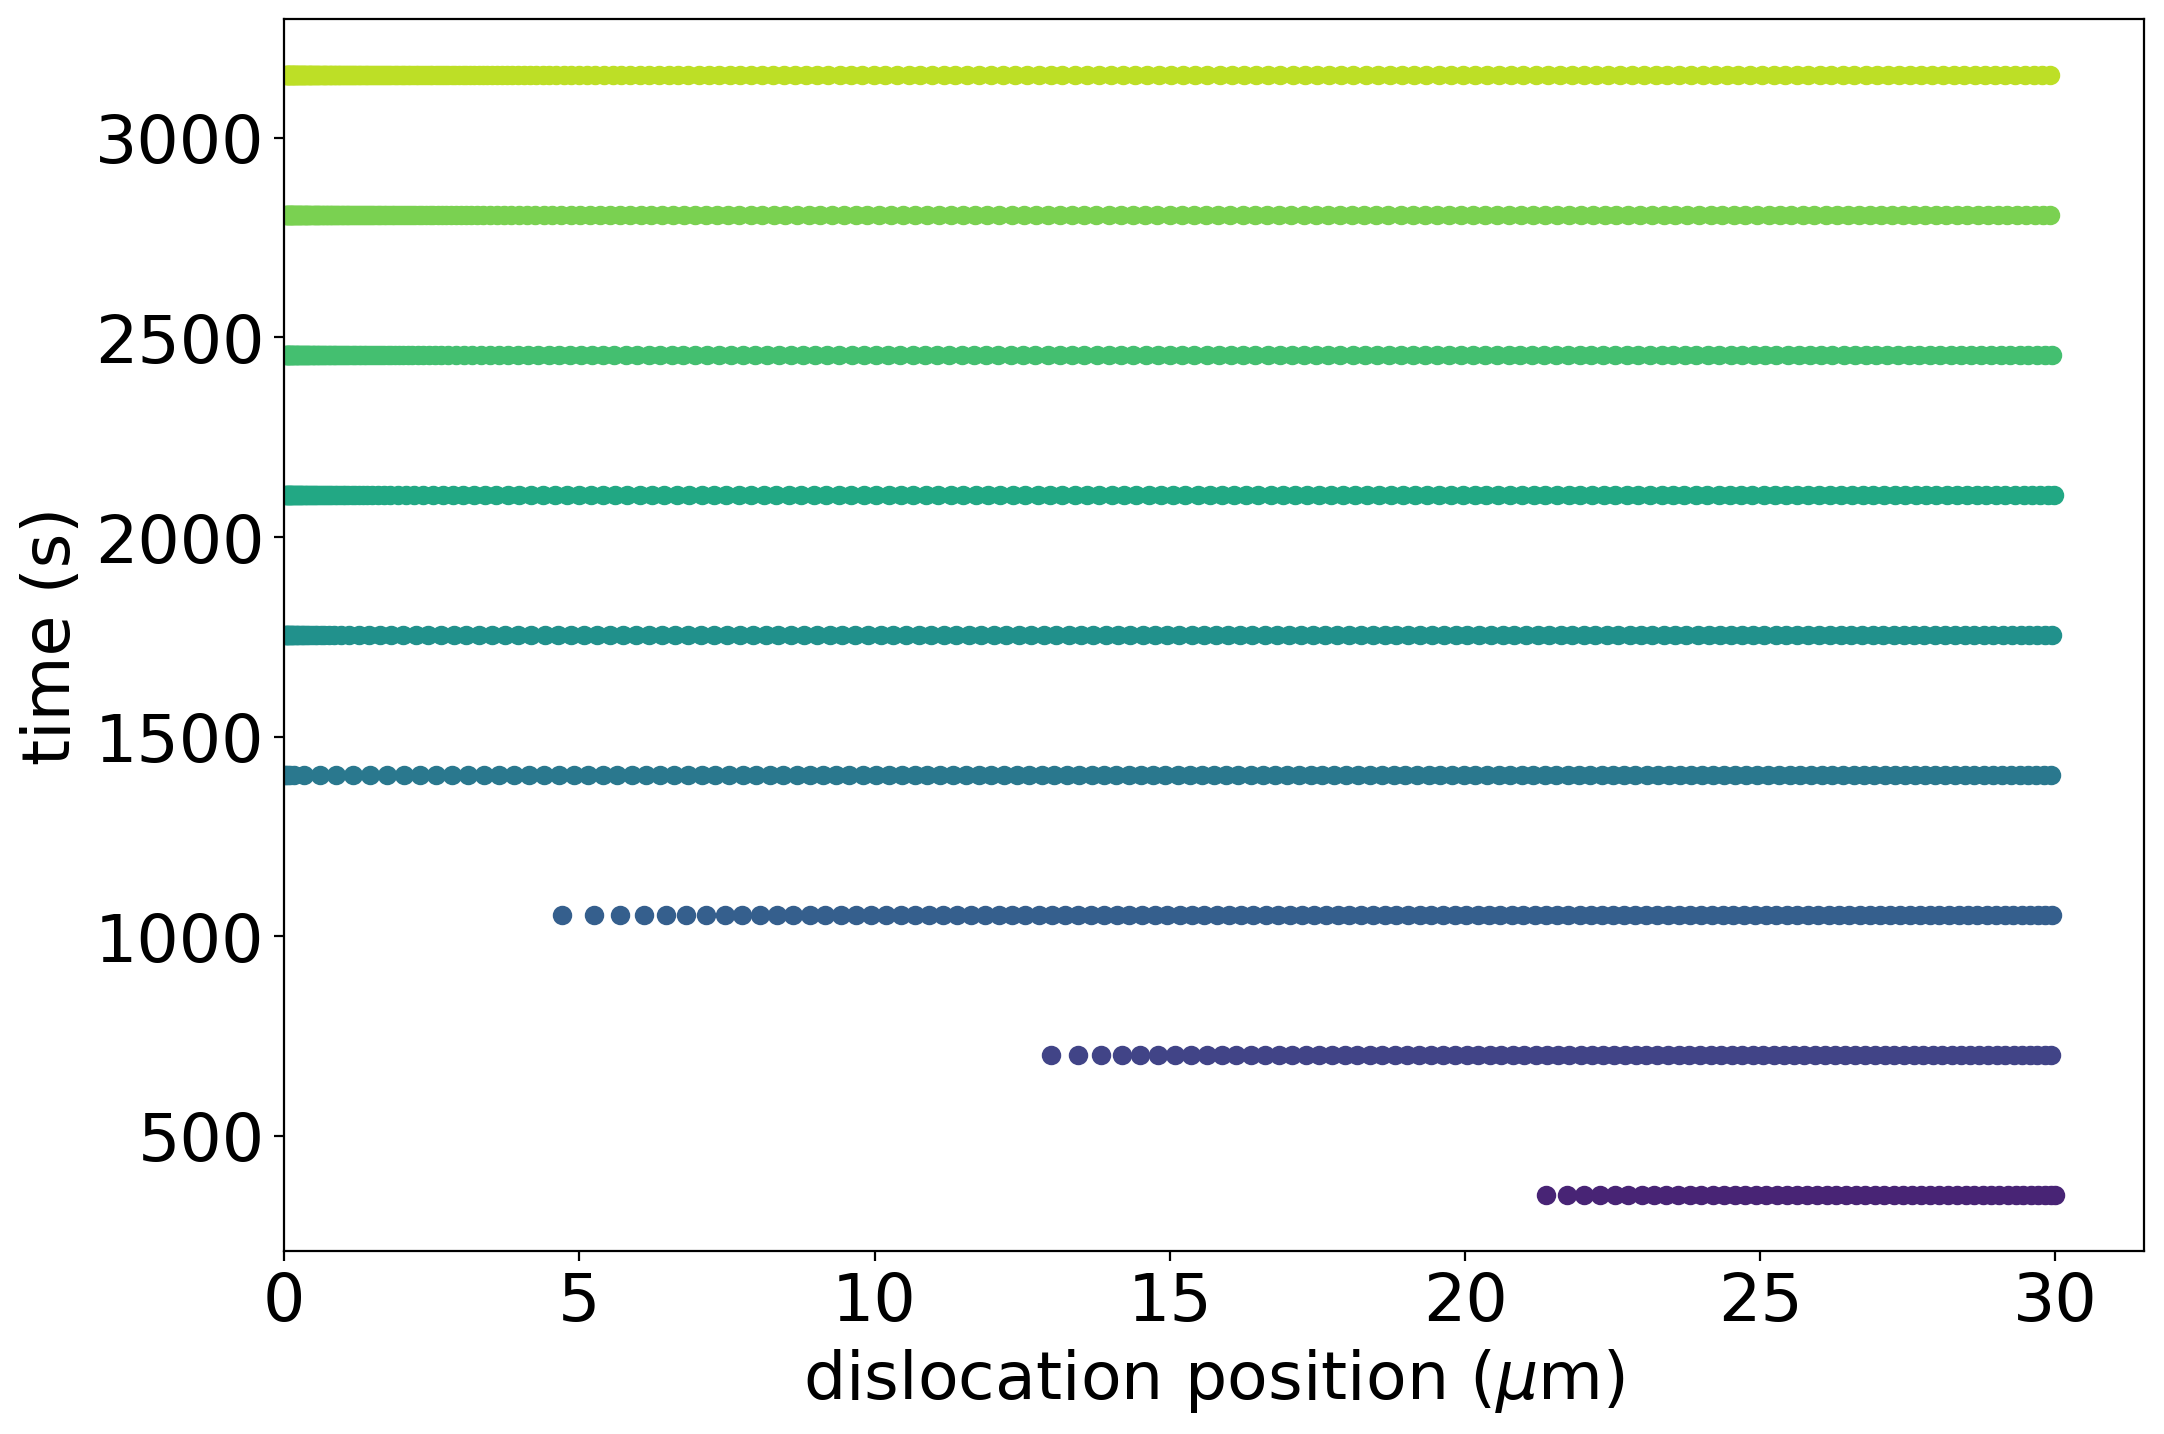

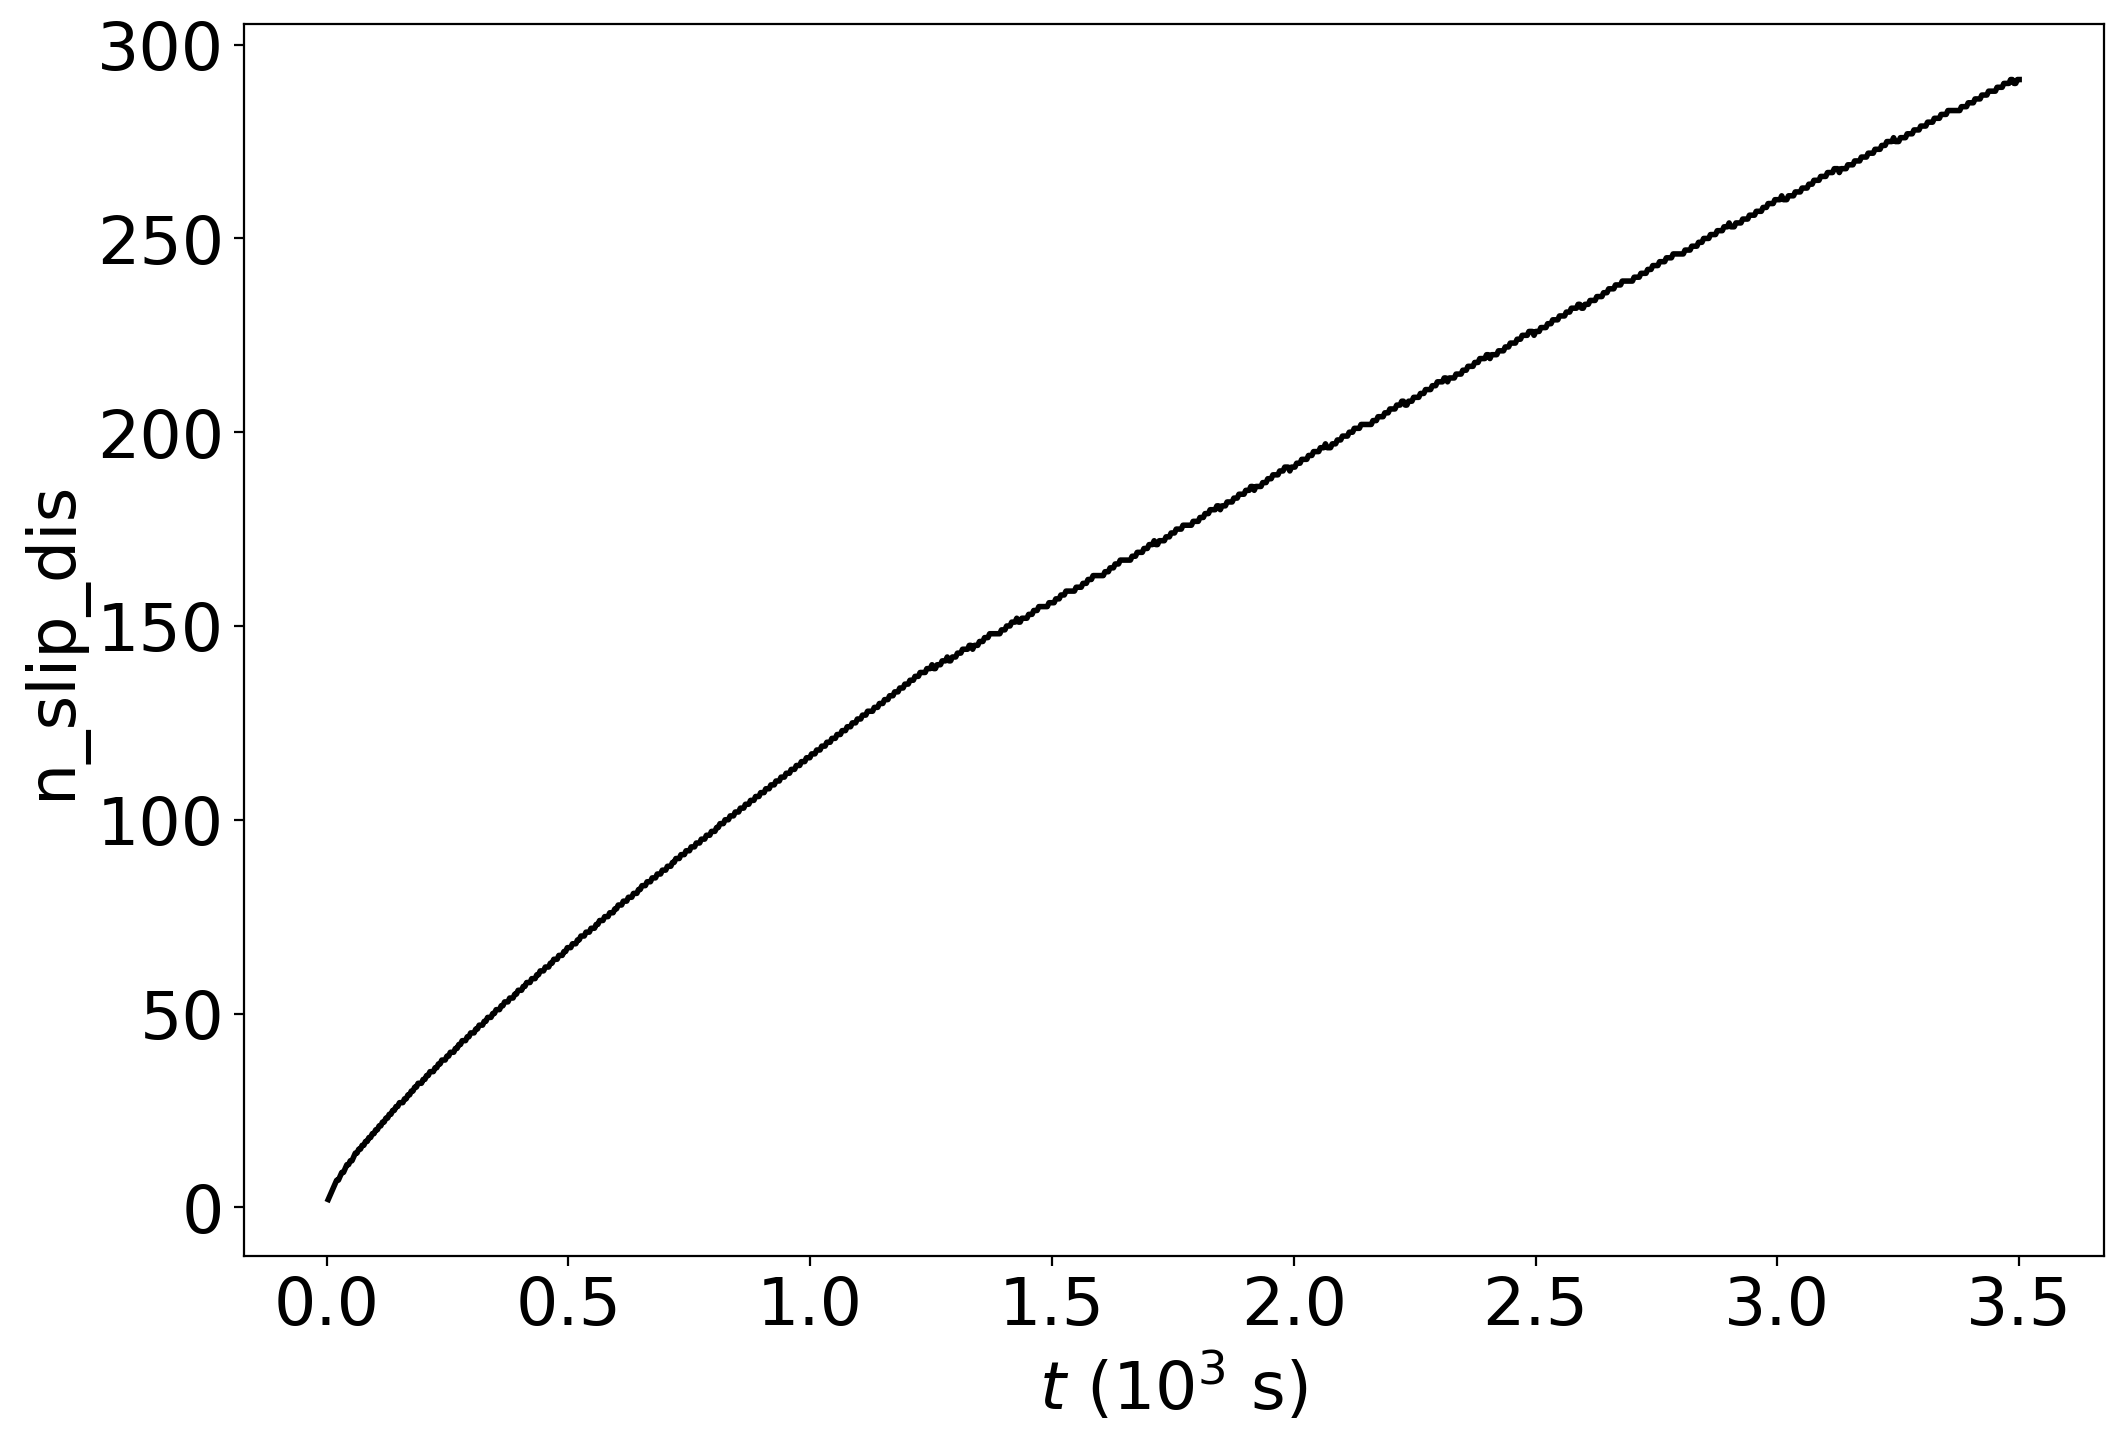

In [16]:
gbdd.plot_pile_up()
gbdd.plot_time_series('n_slip_dis')

Number of dislocations: 152, Simulation time: 1503.0004688795243


/opt/miniconda3/envs/pylabdd/lib/python3.12/site-packages/pylabdd/dislocations.py:190: RuntimeWarning: invalid value encountered in divide
  return self.C * X_arr * (hx - hy) / (hh * hh)


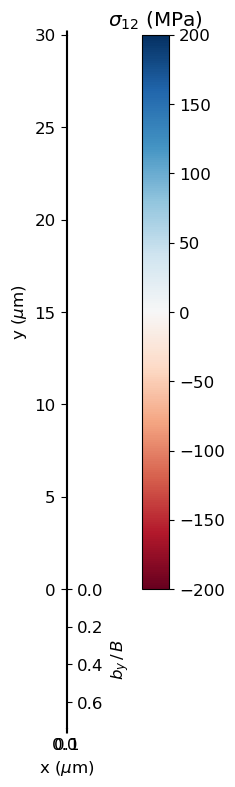

In [12]:
it = 500
plt.rcParams["font.size"] = 12
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(file=f"sigpu_tau{int(gbdd.tau0)}_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf", cutoff=200)


In [ ]:

gbdd.Dgp